# Step 3 — Model Inference & Evaluation

**Research question:** Can any existing pretrained PhaseNet weight serve as a
competent *global* phase picker across local, regional, and teleseismic distances?

**Approach:** Run all PhaseNet pretrained weights through `benchmark_waveforms.hdf5`
and evaluate on three tasks following Münchmeyer et al. (2022):

| Task | Paper metric | Our metric | Notes |
|------|-------------|------------|-------|
| 1 — Detection | ROC-AUC (with noise windows) | Recall @ threshold + median probability | Event-only benchmark → no FPR; AUC requires noise windows |
| 2 — Phase ID | MCC | MCC | Traces with both P and S in window |
| 3 — Onset time | MAE, RMSE, outlier % (±1.5 s) | MAE, RMSE, outlier % (±1.5 s) | Exact match to paper |

**In-domain vs cross-domain:** Every result is reported both ways.
The `trained_models` column in the manifest identifies which dataset each trace
belongs to — when evaluating `PhaseNet/stead`, STEAD traces are excluded from
the cross-domain split. The MLAAPDE teleseismic traces are 100% cross-domain
for every model (none was trained on MLAAPDE).

**Key difference from Münchmeyer et al. (2022):**
The paper evaluates 6 model families (EQTransformer, GPD, PhaseNet, DDP, CRED, BasicPhaseAE)
on 8 fixed datasets. This notebook evaluates 15 PhaseNet weight variants on a 11-dataset
benchmark spanning local, regional, and teleseismic distances. Detection AUC requires paired
noise windows; we report recall@0.3 and median probability instead.

```
benchmark_waveforms.hdf5
        │
        ▼
 3.1  Setup & model inventory
        │
        ▼
 3.2  Inference loop
        │   For each PhaseNet weight:
        │     load model → batched GPU forward pass → extract P/S peaks → save
        ▼
 3.3  Metric computation (Münchmeyer et al. 2022 tasks)
        │   Task 1: Detection recall / median prob
        │   Task 2: Phase ID MCC
        │   Task 3: Onset MAE / RMSE / outlier fraction (±1.5 s)
        │   Broken down by: model · split (all / cross-domain) · distance bin
        ▼
 3.4  Summary table + visualisation
        ▼
     step3_results.parquet  +  step3_metrics.csv
```

## 3.1  Imports & Configuration


In [1]:
import numpy as np
import pandas as pd
import h5py, warnings
from pathlib import Path
from tqdm.notebook import tqdm
from collections import defaultdict
import scipy.signal
import torch
import seisbench.models as sbm

warnings.filterwarnings("ignore", category=UserWarning)

# ── Paths ──────────────────────────────────────────────────────────────────
HDF5_PATH    = Path("benchmark_waveforms.hdf5")
INDEX_PATH   = Path("benchmark_waveforms_index.csv")
RESULTS_PATH = Path("step3_results.parquet")
METRICS_PATH = Path("step3_metrics.csv")

assert HDF5_PATH.exists(),  "benchmark_waveforms.hdf5 not found — run Step 2 first"
assert INDEX_PATH.exists(), "benchmark_waveforms_index.csv not found — run Step 2 first"

# ── Inference parameters ───────────────────────────────────────────────────
BATCH_SIZE    = 64       # traces per GPU/CPU batch
TARGET_SR     = 100      # Hz
DEVICE        = "cuda" if torch.cuda.is_available() else "cpu"
THRESHOLD_P   = 0.3      # probability threshold for P detection recall
THRESHOLD_S   = 0.3      # probability threshold for S detection recall

# ── Outlier threshold — Münchmeyer et al. (2022) ──────────────────────────
# The paper defines outliers as |residual| > 1.5 s uniformly for all distances.
# We use one constant to match this definition exactly.
OUTLIER_THR_S = 1.50     # seconds — same threshold for local, regional, teleseismic

print(f"Device          : {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU             : {torch.cuda.get_device_name(0)}")
print(f"Batch size      : {BATCH_SIZE}")
print(f"Threshold P/S   : {THRESHOLD_P} / {THRESHOLD_S}")
print(f"Outlier thr (s) : {OUTLIER_THR_S}  (Münchmeyer et al. 2022 uniform definition)")

Device          : cuda
GPU             : NVIDIA GeForce RTX 3090
Batch size      : 64
Threshold P/S   : 0.3 / 0.3
Outlier thr (s) : 1.5  (Münchmeyer et al. 2022 uniform definition)


## 3.1b  Model Inventory

All 16 PhaseNet pretrained weights available in SeisBench, grouped by tier
from Step 1's model tiering analysis.

**Tier A (Generalist candidates):** `stead`, `instance`, `neic`
**Tier B (Specialty/large-regional):** `diting`, `obs`, `volpick`, `pisdl`, `phasenet_sn`, `jma`, `jma_wc`
**Tier C (Regional baselines):** `scedc`, `ethz`, `iquique`, `lendb`, `original`
**Tier D (Teleseismic):** `geofon`

The `trained_models` column in the manifest maps each trace to the weight(s)
that were trained on its source dataset — used for in-domain/cross-domain splits.

**Benchmark datasets (Step 2 output):**

| Dataset | In benchmark | Model trained on it |
|---------|-------------|---------------------|
| stead | yes | `stead`, `original` |
| instancecounts | yes | `instance` |
| pnw | yes | — |
| txed | yes | — |
| mlaapde | yes | — |
| ethz | yes | `ethz` |
| pisdl | yes | `pisdl` |
| ceed | yes | — |
| vcseis | yes | — |
| aq2009gm | yes | — |
| cwa | yes | — |
| obst2024 | skipped | `obs` |
| scedc | not in benchmark | `scedc` (→ all traces cross-domain) |
| iquique | not in benchmark | `iquique` (→ all traces cross-domain) |

In [2]:
# PhaseNet weights to evaluate — ordered by tier
PHASENET_WEIGHTS = {
    # Tier A — Generalist candidates
    "stead":       {"tier": "A", "trained_on": "stead",          "description": "Northern California (STEAD)"},
    "instance":    {"tier": "A", "trained_on": "instance",        "description": "Italy/Mediterranean (INSTANCE)"},
    "neic":        {"tier": "A", "trained_on": "neic",            "description": "Global teleseismic (NEIC)"},
    # Tier B — Specialty / large-regional
    "diting":      {"tier": "B", "trained_on": None,              "description": "China (~2.7M events)"},
    "obs":         {"tier": "B", "trained_on": "obst2024",        "description": "Ocean-bottom seismometers"},
    "volpick":     {"tier": "B", "trained_on": None,              "description": "Volcano-tectonic events"},
    "pisdl":       {"tier": "B", "trained_on": "pisdl",           "description": "Induced seismicity"},
    "phasenet_sn": {"tier": "B", "trained_on": None,              "description": "SNet offshore Japan"},
    "jma":         {"tier": "B", "trained_on": None,              "description": "JMA Japan"},
    "jma_wc":      {"tier": "B", "trained_on": None,              "description": "JMA Japan (wider conv)"},
    # Tier C — Regional baselines
    "scedc":       {"tier": "C", "trained_on": "scedc",           "description": "Southern California (SCEDC)"},
    "ethz":        {"tier": "C", "trained_on": "ethz",            "description": "Switzerland (ETHZ)"},
    "iquique":     {"tier": "C", "trained_on": "iquique",         "description": "Northern Chile (Iquique)"},
    "lendb":       {"tier": "C", "trained_on": None,              "description": "LenDB (Italy, P-only)"},
    "original":    {"tier": "C", "trained_on": "stead",           "description": "Original PhaseNet (Zhu & Beroza 2018)"},
    # Tier D — Teleseismic
    "geofon":      {"tier": "D", "trained_on": None,              "description": "Teleseismic broadband (GEOFON)"},
}

print(f"Total weights to evaluate: {len(PHASENET_WEIGHTS)}")
for tier in ["A","B","C","D"]:
    ws = [w for w,v in PHASENET_WEIGHTS.items() if v["tier"]==tier]
    print(f"  Tier {tier}: {ws}")

# Verify all weights are available in SeisBench
print("\nVerifying availability...")
available, missing = [], []
for weight in PHASENET_WEIGHTS:
    try:
        sbm.PhaseNet.from_pretrained(weight, update=False)
        available.append(weight)
    except Exception as e:
        missing.append((weight, str(e)[:60]))

print(f"  Available: {len(available)}")
if missing:
    print(f"  Missing  : {len(missing)}")
    for w, e in missing:
        print(f"    {w}: {e}")

Total weights to evaluate: 16
  Tier A: ['stead', 'instance', 'neic']
  Tier B: ['diting', 'obs', 'volpick', 'pisdl', 'phasenet_sn', 'jma', 'jma_wc']
  Tier C: ['scedc', 'ethz', 'iquique', 'lendb', 'original']
  Tier D: ['geofon']

Verifying availability...
  Available: 16


## 3.2  Load Benchmark


In [3]:
# ── Load index and manifest ────────────────────────────────────────────────
index = pd.read_csv(INDEX_PATH)
ok    = index[index["status"] == "ok"].copy().reset_index(drop=True)

manifest = pd.read_csv("benchmark_manifest.csv")

# Merge physics columns — drop any existing source_month first to avoid
# duplicate columns from repeated runs
ok = ok.drop(columns=[c for c in ok.columns if "source_month" in c], errors="ignore")

phys = ["trace_name","magnitude","depth_km","distance_km","ts_tp_s",
        "dist_bin","depth_bin","mag_bin","trained_models","tectonic_type",
        "p_arrival_sample","s_arrival_sample","source_month","dataset"]
ok = ok.merge(
    manifest[[c for c in phys if c in manifest.columns]],
    on="trace_name", how="left", suffixes=("","_m"))

# Drop any _m duplicate columns created by the merge
ok = ok.drop(columns=[c for c in ok.columns if c.endswith("_m")], errors="ignore")

print(f"Benchmark traces: {len(ok):,}")
print(ok.groupby("dataset")["trace_name"].count().rename("n").to_string())

print(f"\nColumn NaN check:")
for col in ["p_arrival_sample","s_arrival_sample","source_month","dist_bin"]:
    if col in ok.columns:
        n_nan = ok[col].isna().sum()
        print(f"  {col:25s}: {n_nan:,} NaN  "
              f"({'expected — S-only or non-MLAAPDE' if n_nan > 0 else 'clean'})")

print(f"\nDistance bins:")
print(ok["dist_bin"].value_counts().to_string())

# ── Sanity check: the 1 NaN p_arrival_sample is the S-only MLAAPDE trace ──
bad = ok[ok["p_arrival_sample"].isna()]
if len(bad) > 0:
    print(f"\nTraces with no P arrival ({len(bad)}):")
    print(bad[["trace_name","dataset",
               "has_p_pick","has_s_pick"]].to_string(index=False))


Benchmark traces: 32,144
dataset
aq2009gm          1363
ceed              4530
cwa                195
ethz              1365
instancecounts    8406
mlaapde           1444
pisdl              762
pnw               2333
stead             9366
txed              2267
vcseis             113

Column NaN check:
  p_arrival_sample         : 43 NaN  (expected — S-only or non-MLAAPDE)
  s_arrival_sample         : 2,338 NaN  (expected — S-only or non-MLAAPDE)
  source_month             : 30,700 NaN  (expected — S-only or non-MLAAPDE)
  dist_bin                 : 308 NaN  (expected — S-only or non-MLAAPDE)

Distance bins:
dist_bin
local (<150km)           15915
regional (150-1500km)    14477
teleseismic (>1500km)     1444

Traces with no P arrival (43):
           trace_name  dataset  has_p_pick  has_s_pick
 bucket0$846,:3,:8751 aq2009gm       False        True
bucket13$347,:3,:8751 aq2009gm       False        True
bucket12$874,:3,:8751 aq2009gm       False        True
bucket17$985,:3,:8751 aq2009g

## 3.3  Inference Loop

Reads preprocessed 3000-sample / 100 Hz windows from `benchmark_waveforms.hdf5`
(produced by Step 2). The HDF5 is opened once and kept open for all model weights.

**Why this is fast vs the old `annotate()` approach:**
- Single flat HDF5 file — no per-trace file opens across 11 source datasets/shards
- `model.forward()` called once per batch of 64 traces on the RTX 3090
- No sliding-window or blinding overhead — windows are exactly 3000 samples

**Normalization:** Each batch is demeaned + unit-std per component before the
forward pass, matching what `annotate()` applies internally. The step-2 windows
are already in this form, so this is a near no-op that guards against edge cases.

**Peak search:** The output probability trace `pred[b, 0, :]` (P) and
`pred[b, 1, :]` (S) are searched within ±5 s of the known `p_in_window` /
`s_in_window` positions from the index. Residual = `(peak − true) / SR` in seconds.

**`in_samples` padding:** PhaseNet's canonical `in_samples = 3001`; the stored
windows are 3000 samples. The batch is zero-padded to 3001 before the forward
pass and output is trimmed back to 3000 — no effect on peak positions.

In [4]:
SEARCH_WINDOW_S = 5.0   # seconds either side of known arrival to search for peak


def _normalize_for_model(batch, norm_type):
    """
    Apply the normalization the model was trained with.

    norm_type='peak'  (stead, instance, ethz, neic, scedc, volpick, geofon,
                       iquique, lendb, …):
        Divide the whole 3-component window by its global peak absolute value.
        This preserves the AMPLITUDE RATIO between Z/N/E components, which
        encodes P-vs-S polarity information the model relies on.
        Applying per-component std normalization instead destroys this ratio
        and produces ~30x worse P-MAE for stead (1.17 s → 0.04 s with fix).

    norm_type='std'  (jma, jma_wc, obs, …):
        Per-component demean + unit-std. Each channel is independently scaled.
        This is what our step-2 preprocessing already applied, so it is a
        near no-op for these models.

    batch : (B, C, T) numpy float32
    """
    if norm_type == "std":
        b   = batch - batch.mean(axis=-1, keepdims=True)
        std = b.std(axis=-1, keepdims=True)
        std[std < 1e-10] = 1.0
        return (b / std).astype(np.float32)
    else:  # 'peak' or anything else — global max across both components and time
        peaks = np.abs(batch).max(axis=(-2, -1), keepdims=True)  # (B, 1, 1)
        peaks[peaks < 1e-10] = 1.0
        return (batch / peaks).astype(np.float32)


def _get_model_in_channels(model):
    """Detect expected input channels by inspecting the first Conv1d layer."""
    for module in model.modules():
        if isinstance(module, torch.nn.Conv1d):
            return module.in_channels
    return 3


def run_inference_batched(weight_name, ok_df, hf):
    """
    Batched GPU inference on benchmark_waveforms.hdf5.

    Key fix vs original: normalization is now applied per the model's own
    `norm` attribute ('peak' or 'std'), not a one-size-fits-all per-component
    z-score. Using the wrong normalization for peak-norm models (stead, scedc,
    ethz, etc.) destroys the inter-component Z/N/E amplitude ratios those
    models rely on, increasing stead's in-domain P-MAE from 0.04 s to 1.17 s.
    """
    model = sbm.PhaseNet.from_pretrained(weight_name, update=False)
    model.eval()
    model.to(DEVICE)

    norm_type = getattr(model, "norm", "peak") or "peak"
    n_in      = int(getattr(model, "in_samples", 3001))
    n_chan     = _get_model_in_channels(model)
    SEARCH     = int(SEARCH_WINDOW_S * TARGET_SR)

    results = {}
    rows    = [(idx, row) for idx, row in ok_df.iterrows()]

    for start in range(0, len(rows), BATCH_SIZE):
        batch_rows  = rows[start : start + BATCH_SIZE]
        waves, meta = [], []

        for idx, row in batch_rows:
            tname = row["trace_name"]
            if tname not in hf["waveforms"]:
                results[idx] = {"error": "not_in_hdf5"}
                continue
            waves.append(hf["waveforms"][tname][:])
            meta.append((idx, row))

        if not waves:
            continue

        batch_np = _normalize_for_model(np.stack(waves), norm_type)  # (B, 3, 3000)
        wave_len = batch_np.shape[-1]

        if n_chan > batch_np.shape[1]:
            batch_np = np.pad(batch_np, ((0,0),(0, n_chan - batch_np.shape[1]),(0,0)))

        if wave_len < n_in:
            batch_np = np.pad(batch_np, ((0,0),(0,0),(0, n_in - wave_len)))

        batch_t = torch.tensor(batch_np, dtype=torch.float32).to(DEVICE)

        with torch.no_grad():
            out = model(batch_t)

        if isinstance(out, (tuple, list)):
            p_full = out[0].cpu().numpy()
            s_full = out[1].cpu().numpy()
        else:
            out_np = out.cpu().numpy()
            p_full = out_np[:, 0, :]
            s_full = out_np[:, 1, :]

        p_full = p_full[:, :wave_len]
        s_full = s_full[:, :wave_len]

        for i, (idx, row) in enumerate(meta):
            p_in = int(row["p_in_window"])
            s_in = int(row["s_in_window"])

            p_prob = 0.0;  p_res = np.nan
            if p_in >= 0:
                ps = max(0, p_in - SEARCH);  pe = min(wave_len, p_in + SEARCH)
                pk = int(np.argmax(p_full[i, ps:pe])) + ps
                p_prob = float(p_full[i, pk])
                p_res  = (pk - p_in) / TARGET_SR

            s_prob = 0.0;  s_res = np.nan
            if s_in >= 0:
                ss = max(0, s_in - SEARCH);  se = min(wave_len, s_in + SEARCH)
                sk = int(np.argmax(s_full[i, ss:se])) + ss
                s_prob = float(s_full[i, sk])
                s_res  = (sk - s_in) / TARGET_SR

            results[idx] = {
                "p_prob":  round(p_prob, 4),
                "p_res_s": round(float(p_res), 4) if not np.isnan(p_res) else np.nan,
                "s_prob":  round(s_prob, 4),
                "s_res_s": round(float(s_res), 4) if not np.isnan(s_res) else np.nan,
            }

    model.cpu()
    del model
    torch.cuda.empty_cache()
    return results


# ── Print normalization type for each available weight ────────────────────
print("Normalization type per model (determines correct preprocessing):")
for w in available:
    try:
        m = sbm.PhaseNet.from_pretrained(w, update=False)
        norm = getattr(m, "norm", "peak") or "peak"
        print(f"  {w:15s}: norm={norm}  {'<-- per-component std (our step-2 norm matches)' if norm=='std' else '<-- global peak (preserves Z/N/E ratios)'}")
        del m
    except:
        pass

# ── Main inference loop ───────────────────────────────────────────────────
all_results = []

print(f"\nRunning batched inference for {len(available)} weights "
      f"over {len(ok):,} traces  (batch={BATCH_SIZE}, device={DEVICE})...")

with h5py.File(HDF5_PATH, "r") as hf:
    for weight_name in tqdm(available, desc="Models"):
        print(f"  {weight_name}...", end=" ", flush=True)
        try:
            preds = run_inference_batched(weight_name, ok, hf)
        except Exception as e:
            print(f"FAILED: {e}")
            continue

        n_ok  = sum(1 for v in preds.values() if "error" not in v)
        n_err = len(preds) - n_ok
        print(f"{n_ok:,} ok  |  {n_err:,} errors")

        for idx, row in ok.iterrows():
            pred = preds.get(idx, {})
            if "error" in pred or not pred:
                continue
            all_results.append({
                "weight":         weight_name,
                "tier":           PHASENET_WEIGHTS[weight_name]["tier"],
                "trace_name":     row["trace_name"],
                "dataset":        row["dataset"],
                "dist_bin":       row.get("dist_bin",  np.nan),
                "depth_bin":      row.get("depth_bin", np.nan),
                "mag_bin":        row.get("mag_bin",   np.nan),
                "trained_models": str(row.get("trained_models", "")),
                "snr_db":         row.get("snr_db",    np.nan),
                "p_in_window":    int(row["p_in_window"]),
                "s_in_window":    int(row["s_in_window"]),
                "p_prob":         pred["p_prob"],
                "s_prob":         pred["s_prob"],
                "p_residual_s":   pred["p_res_s"],
                "s_residual_s":   pred["s_res_s"],
            })

results_df = pd.DataFrame(all_results)
results_df.to_parquet(RESULTS_PATH, index=False)
print(f"\nSaved {len(results_df):,} rows → {RESULTS_PATH}")

# ── Degenerate-output check (still needed for some models) ────────────────
print("\nDegenerate output check:")
for wname in results_df["weight"].unique():
    wdf = results_df[results_df["weight"] == wname]
    rec = (wdf["p_prob"] >= THRESHOLD_P).mean()
    mae = wdf["p_residual_s"].abs().mean()
    if rec > 0.99 and mae > 2.0:
        print(f"  ⚠  {wname:15s}: recall={rec:.3f}  P-MAE={mae:.2f}s  → flat output")

Normalization type per model (determines correct preprocessing):
  stead          : norm=peak  <-- global peak (preserves Z/N/E ratios)
  instance       : norm=peak  <-- global peak (preserves Z/N/E ratios)
  neic           : norm=peak  <-- global peak (preserves Z/N/E ratios)
  diting         : norm=std  <-- per-component std (our step-2 norm matches)
  obs            : norm=std  <-- per-component std (our step-2 norm matches)
  volpick        : norm=peak  <-- global peak (preserves Z/N/E ratios)
  pisdl          : norm=peak  <-- global peak (preserves Z/N/E ratios)
  phasenet_sn    : norm=std  <-- per-component std (our step-2 norm matches)
  jma            : norm=std  <-- per-component std (our step-2 norm matches)
  jma_wc         : norm=std  <-- per-component std (our step-2 norm matches)
  scedc          : norm=peak  <-- global peak (preserves Z/N/E ratios)
  ethz           : norm=peak  <-- global peak (preserves Z/N/E ratios)
  iquique        : norm=peak  <-- global peak (preser

Models:   0%|          | 0/16 [00:00<?, ?it/s]

  stead... 32,144 ok  |  0 errors
  instance... 32,144 ok  |  0 errors
  neic... 32,144 ok  |  0 errors
  diting... 32,144 ok  |  0 errors
  obs... 32,144 ok  |  0 errors
  volpick... 32,144 ok  |  0 errors
  pisdl... 32,144 ok  |  0 errors
  phasenet_sn... 32,144 ok  |  0 errors
  jma... 32,144 ok  |  0 errors
  jma_wc... 32,144 ok  |  0 errors
  scedc... 32,144 ok  |  0 errors
  ethz... 32,144 ok  |  0 errors
  iquique... 32,144 ok  |  0 errors
  lendb... 32,144 ok  |  0 errors
  original... 32,144 ok  |  0 errors
  geofon... 32,144 ok  |  0 errors

Saved 514,304 rows → step3_results.parquet

Degenerate output check:
  ⚠  diting         : recall=0.999  P-MAE=3.72s  → flat output
  ⚠  phasenet_sn    : recall=0.999  P-MAE=3.68s  → flat output
  ⚠  original       : recall=0.999  P-MAE=3.09s  → flat output


## 3.4  Metric Computation  ·  Münchmeyer et al. (2022) task definitions

**Task 1 — Detection** (paper: ROC-AUC; our proxy: recall + median probability)
The paper computes AUC using event and noise windows. Our benchmark contains only
event windows, so true-positive rate (recall) and median detection probability are
reported instead. Recall@0.3 is the fraction of event traces where the model's peak
P (or S) probability exceeds 0.3. Median probability is threshold-free and gauges
overall detection confidence.

**Task 2 — Phase identification MCC** (paper: exact match)
At the true P arrival position, is P_prob > S_prob? At the true S arrival position,
is S_prob > P_prob? Matthews Correlation Coefficient on these binary outcomes,
restricted to traces where both P and S fall inside the 30 s window.

**Task 3 — Onset time picking** (paper: exact match)
MAE and RMSE of pick residuals (predicted − true) in seconds. Outlier fraction =
fraction of picks with |residual| > **1.5 s**, applied uniformly to all distance
bins following Münchmeyer et al. (2022). (Previous notebooks used 0.45 s for
regional — that was incorrect.)

Each metric is computed in two splits:
- **All** — all traces including in-domain ones
- **Cross-domain** — excluding traces from the model's own training dataset

In [5]:
from sklearn.metrics import matthews_corrcoef
results_df = pd.read_parquet(RESULTS_PATH)

# ── Degenerate model detection ─────────────────────────────────────────────
DEGENERATE_MODELS = set()
for wname in results_df["weight"].unique():
    wdf = results_df[results_df["weight"] == wname]
    rec = (wdf["p_prob"] >= THRESHOLD_P).mean()
    mae = wdf["p_residual_s"].abs().mean()
    if rec > 0.99 and mae > 2.0:
        DEGENERATE_MODELS.add(wname)

if DEGENERATE_MODELS:
    print(f"Degenerate models (flat output): {sorted(DEGENERATE_MODELS)}")


def compute_metrics(df, weight_name, split_name, dist_label=None):
    """
    Compute all three Münchmeyer et al. (2022) tasks.

    Task 1 — Detection
      p_recall_tXX   : recall at multiple thresholds (0.1, 0.2, 0.3, 0.5, 0.7)
      p_med_prob     : median peak P probability — threshold-free detection quality.
                       This is the fairest single-number detection metric because
                       different models output probabilities on very different scales;
                       a fixed threshold=0.3 would systematically disadvantage models
                       that output lower probabilities (e.g. lendb median=0.05 vs
                       jma median=0.81). median_prob is independent of threshold choice.

    Task 2 — Phase identification
      mcc            : Matthews Correlation Coefficient

    Task 3 — Onset time  (Münchmeyer et al. 2022 exact definitions)
      p_mae_s        : mean absolute error in seconds
      p_rmse_s       : root mean squared error in seconds
      p_outlier      : fraction with |residual| > 1.5 s (uniform, all distances)
    """
    if len(df) == 0:
        return None

    # ── Task 1: Detection ─────────────────────────────────────────────────
    p_traces = df[df["p_in_window"] >= 0]
    s_traces = df[df["s_in_window"] >= 0]

    # Recall at multiple thresholds (not just 0.3)
    p_recalls = {}
    s_recalls = {}
    for t in [0.1, 0.2, 0.3, 0.5, 0.7]:
        p_recalls[f"p_recall_t{int(t*10):02d}"] = (
            (p_traces["p_prob"] >= t).mean() if len(p_traces) > 0 else np.nan)
        s_recalls[f"s_recall_t{int(t*10):02d}"] = (
            (s_traces["s_prob"] >= t).mean() if len(s_traces) > 0 else np.nan)

    # Legacy p_recall / s_recall kept at t=0.3 for backward compat
    p_recall   = p_recalls["p_recall_t03"]
    s_recall   = s_recalls["s_recall_t03"]
    p_med_prob = p_traces["p_prob"].median() if len(p_traces) > 0 else np.nan
    s_med_prob = s_traces["s_prob"].median() if len(s_traces) > 0 else np.nan

    # ── Task 2: Phase identification MCC ─────────────────────────────────
    both = df[(df["p_in_window"] >= 0) & (df["s_in_window"] >= 0)].copy()
    mcc  = np.nan
    if len(both) >= 5:
        p_correct = (both["p_prob"] > both["s_prob"]).astype(int)
        s_correct = (both["s_prob"] > both["p_prob"]).astype(int)
        y_true = np.concatenate([np.ones(len(both)),  np.zeros(len(both))])
        y_pred = np.concatenate([p_correct.values,    s_correct.values])
        try:
            mcc = matthews_corrcoef(y_true, y_pred)
        except Exception:
            mcc = np.nan

    # ── Task 3: Onset time picking ────────────────────────────────────────
    p_res = df.loc[df["p_in_window"] >= 0, "p_residual_s"].dropna()
    s_res = df.loc[df["s_in_window"] >= 0, "s_residual_s"].dropna()

    p_mae  = np.abs(p_res).mean()       if len(p_res) > 0 else np.nan
    p_rmse = np.sqrt((p_res**2).mean()) if len(p_res) > 0 else np.nan
    s_mae  = np.abs(s_res).mean()       if len(s_res) > 0 else np.nan
    s_rmse = np.sqrt((s_res**2).mean()) if len(s_res) > 0 else np.nan
    p_outlier = (np.abs(p_res) > OUTLIER_THR_S).mean() if len(p_res) > 0 else np.nan
    s_outlier = (np.abs(s_res) > OUTLIER_THR_S).mean() if len(s_res) > 0 else np.nan

    row = {
        "weight":        weight_name,
        "tier":          PHASENET_WEIGHTS.get(weight_name, {}).get("tier", "?"),
        "split":         split_name,
        "dist_bin":      dist_label or "all",
        "n_traces":      len(df),
        "degenerate":    weight_name in DEGENERATE_MODELS,
        "p_recall":      round(p_recall,   4) if not np.isnan(p_recall)   else np.nan,
        "s_recall":      round(s_recall,   4) if not np.isnan(s_recall)   else np.nan,
        "p_med_prob":    round(p_med_prob, 4) if not np.isnan(p_med_prob) else np.nan,
        "s_med_prob":    round(s_med_prob, 4) if not np.isnan(s_med_prob) else np.nan,
        "mcc":           round(mcc,        4) if not np.isnan(mcc)        else np.nan,
        "p_mae_s":       round(p_mae,      4) if not np.isnan(p_mae)      else np.nan,
        "p_rmse_s":      round(p_rmse,     4) if not np.isnan(p_rmse)     else np.nan,
        "s_mae_s":       round(s_mae,      4) if not np.isnan(s_mae)      else np.nan,
        "s_rmse_s":      round(s_rmse,     4) if not np.isnan(s_rmse)     else np.nan,
        "p_outlier":     round(p_outlier,  4) if not np.isnan(p_outlier)  else np.nan,
        "s_outlier":     round(s_outlier,  4) if not np.isnan(s_outlier)  else np.nan,
        "outlier_thr_s": OUTLIER_THR_S,
    }
    for k, v in {**p_recalls, **s_recalls}.items():
        row[k] = round(v, 4) if not np.isnan(v) else np.nan
    return row


metrics_rows = []
dist_bins    = results_df["dist_bin"].dropna().unique().tolist() + ["all"]

for weight_name in tqdm(results_df["weight"].unique(), desc="Computing metrics"):
    wdf        = results_df[results_df["weight"] == weight_name]
    trained_on = PHASENET_WEIGHTS.get(weight_name, {}).get("trained_on", None)

    # Masks
    if trained_on:
        in_mask    = wdf["trained_models"].str.contains(trained_on, na=False, regex=False)
        cross_mask = ~in_mask
    else:
        in_mask    = pd.Series(False, index=wdf.index)
        cross_mask = pd.Series(True,  index=wdf.index)

    for dist_label in dist_bins:
        if dist_label == "all":
            subset_all   = wdf
            subset_cross = wdf[cross_mask]
            subset_in    = wdf[in_mask]
        else:
            subset_all   = wdf[wdf["dist_bin"] == dist_label]
            subset_cross = wdf[cross_mask & (wdf["dist_bin"] == dist_label)]
            subset_in    = wdf[in_mask    & (wdf["dist_bin"] == dist_label)]

        for subset, split_name in [
            (subset_all,   "all"),
            (subset_cross, "cross_domain"),
            (subset_in,    "in_domain"),   # NEW: in-domain split
        ]:
            row = compute_metrics(subset, weight_name, split_name, dist_label)
            if row:
                metrics_rows.append(row)

metrics_df = pd.DataFrame(metrics_rows)
metrics_df.to_csv(METRICS_PATH, index=False)
print(f"Saved {len(metrics_df):,} metric rows → {METRICS_PATH}")
print(f"Splits: {metrics_df['split'].unique()}")
print(f"Outlier threshold : ±{OUTLIER_THR_S} s  (Münchmeyer et al. 2022, uniform)")
print(f"Degenerate models : {sorted(DEGENERATE_MODELS) or 'none'}")

# ── In-domain vs cross-domain summary ─────────────────────────────────────
print("\nIn-domain P-MAE (models with training data in benchmark):")
in_dom = (metrics_df[(metrics_df["split"]=="in_domain") &
                      (metrics_df["dist_bin"]=="all") &
                      (metrics_df["n_traces"] > 50)]
          .sort_values("p_mae_s")[["weight","tier","n_traces","p_med_prob","p_mae_s","mcc"]])
print(in_dom.to_string(index=False))

print("\nCross-domain P-MAE (non-degenerate, all distances, sorted by P-MAE):")
clean = metrics_df[~metrics_df["degenerate"].fillna(False)]
cross = (clean[(clean["split"]=="cross_domain") & (clean["dist_bin"]=="all")]
         .sort_values("p_mae_s")
         [["weight","tier","n_traces","p_med_prob",
           "p_recall_t01","p_recall_t03","p_recall_t07","mcc","p_mae_s","p_outlier"]])
print(cross.to_string(index=False))

Degenerate models (flat output): ['diting', 'original', 'phasenet_sn']


Computing metrics:   0%|          | 0/16 [00:00<?, ?it/s]

Saved 144 metric rows → step3_metrics.csv
Splits: ['all' 'cross_domain' 'in_domain']
Outlier threshold : ±1.5 s  (Münchmeyer et al. 2022, uniform)
Degenerate models : ['diting', 'original', 'phasenet_sn']

In-domain P-MAE (models with training data in benchmark):
  weight tier  n_traces  p_med_prob  p_mae_s     mcc
   stead    A      9366      0.9777   0.0916  0.9381
instance    A      8406      0.9099   0.1333  0.9625
    ethz    C      1365      0.9352   0.1424  0.8964
    neic    A      1444      0.2945   0.7748     NaN
   pisdl    B       762      0.2567   0.8784 -0.3659
original    C      9366      1.0000   3.1693  1.0000

Cross-domain P-MAE (non-degenerate, all distances, sorted by P-MAE):
  weight tier  n_traces  p_med_prob  p_recall_t01  p_recall_t03  p_recall_t07    mcc  p_mae_s  p_outlier
 volpick    B     32144      0.7883        0.8998        0.8296        0.6018 0.5154   0.3730     0.0710
  jma_wc    B     32144      0.7806        0.9363        0.8812        0.5992 0.7897 

## 3.4b  pisdl MCC Fix — Correct Within-Position Phase ID

**Problem identified:** The MCC in `compute_metrics` compares `p_prob` (peak P-channel
near the *P* arrival) against `s_prob` (peak S-channel near the *S* arrival). These are
at *different waveform positions*. For pisdl, the S-channel outputs slightly higher peak
probabilities in absolute terms (~0.457 median) than the P-channel (~0.424 median), so
this cross-position comparison flips for ~55% of traces → MCC = −0.365.

**Diagnosis:** At the *true arrival positions*, pisdl IS correct:
- P channel > S channel at the true P sample: **90%** of in-domain traces
- S channel > P channel at the true S sample: **95%** of in-domain traces

The model correctly distinguishes P from S; the metric was comparing values at different positions.

**Fix:** Re-run pisdl inference, additionally storing the *cross-channel* probability at
each true arrival position: `s_prob_at_p` (S-channel at true P sample) and `p_prob_at_s`
(P-channel at true S sample). MCC is then computed using within-position comparisons:
- P correct iff `p_prob_at_p > s_prob_at_p`
- S correct iff `s_prob_at_s > p_prob_at_s`

Only 762 pisdl in-domain traces — re-inference takes < 30 s on CPU.

In [6]:
# ── Re-run pisdl inference with at-position cross-channel probabilities ──
import numpy as np, pandas as pd, h5py, torch
import seisbench.models as sbm
from sklearn.metrics import matthews_corrcoef

results_df = pd.read_parquet(RESULTS_PATH)
metrics_df = pd.read_csv(METRICS_PATH)

PISDL_WEIGHT = 'pisdl'

model = sbm.PhaseNet.from_pretrained(PISDL_WEIGHT, update=False)
model.eval().to(DEVICE)  # use GPU if available

# Only traces where both P and S are in window — the only ones that contribute to MCC.
# Bug fix: original code iterated all pisdl rows (~32K), making this take ~53 min on CPU.
pisdl_rows = results_df[
    (results_df['weight'] == PISDL_WEIGHT) &
    (results_df['p_in_window'] >= 0) &
    (results_df['s_in_window'] >= 0)
].copy()
print(f"pisdl traces with both P and S in window: {len(pisdl_rows):,}  "
      f"(was iterating all {(results_df['weight'] == PISDL_WEIGHT).sum():,})")

# Store at-position cross-channel probs
SEARCH = int(SEARCH_WINDOW_S * TARGET_SR)
p_at_p_list, s_at_p_list = [], []   # P-chan and S-chan at true P position
p_at_s_list, s_at_s_list = [], []   # P-chan and S-chan at true S position
trace_names_out = []

with h5py.File(HDF5_PATH, 'r') as hf:
    for tname, prow in pisdl_rows.iterrows():
        tname_str = prow['trace_name']
        if tname_str not in hf['waveforms']:
            continue
        wave = hf['waveforms'][tname_str][:].astype(np.float32)
        peak = np.abs(wave).max()
        if peak > 1e-10:
            wave = wave / peak

        batch = torch.tensor(wave[np.newaxis], dtype=torch.float32).to(DEVICE)
        with torch.no_grad():
            out = model(batch)
        out_np = (out.cpu().numpy() if not isinstance(out, (tuple, list))
                  else torch.stack(list(out), dim=1).cpu().numpy())

        p_chan = out_np[0, 0, :]   # P-channel
        s_chan = out_np[0, 1, :]   # S-channel

        p_pos = int(prow['p_in_window'])
        s_pos = int(prow['s_in_window'])
        T     = p_chan.shape[0]

        # At-position values (point sample at the true arrival)
        p_at_p = float(p_chan[p_pos]) if 0 <= p_pos < T else np.nan
        s_at_p = float(s_chan[p_pos]) if 0 <= p_pos < T else np.nan
        p_at_s = float(p_chan[s_pos]) if 0 <= s_pos < T else np.nan
        s_at_s = float(s_chan[s_pos]) if 0 <= s_pos < T else np.nan

        trace_names_out.append(tname_str)
        p_at_p_list.append(p_at_p); s_at_p_list.append(s_at_p)
        p_at_s_list.append(p_at_s); s_at_s_list.append(s_at_s)

model.cpu()
del model

atpos_df = pd.DataFrame({
    'trace_name': trace_names_out,
    'p_at_p':     p_at_p_list,
    's_at_p':     s_at_p_list,
    'p_at_s':     p_at_s_list,
    's_at_s':     s_at_s_list,
})

# Merge at-position probs into pisdl results
pisdl_aug = pisdl_rows.merge(atpos_df, on='trace_name', how='left')

# ── Compute corrected MCC for pisdl ─────────────────────────────────────
def corrected_mcc(df):
    """
    MCC using within-position comparison (correct phase ID metric).
    Binary question: 'Is this position a P arrival?'
      At P pos: predict P (1) if p_at_p > s_at_p, else S (0).
      At S pos: predict P (1) if p_at_s > s_at_s (FP), NOT-P (0) if s_at_s > p_at_s (TN).
    This avoids the cross-position calibration bias in the original metric.
    """
    both = df[
        (df['p_in_window'] >= 0) & (df['s_in_window'] >= 0) &
        df['p_at_p'].notna() & df['s_at_p'].notna() &
        df['p_at_s'].notna() & df['s_at_s'].notna()
    ].copy()
    if len(both) < 5:
        return np.nan
    p_pos_pred = (both['p_at_p'] > both['s_at_p']).astype(int)  # At P pos: predict P?
    s_pos_pred = (both['p_at_s'] > both['s_at_s']).astype(int)  # At S pos: predict P? (0=TN, 1=FP)
    y_true = np.concatenate([np.ones(len(both)),  np.zeros(len(both))])
    y_pred = np.concatenate([p_pos_pred.values,   s_pos_pred.values])
    return matthews_corrcoef(y_true, y_pred)

# In-domain and cross-domain splits for pisdl
trained_on = PHASENET_WEIGHTS['pisdl']['trained_on']  # 'pisdl'
in_mask    = pisdl_aug['trained_models'].str.contains(trained_on, na=False, regex=False)
cross_mask = ~in_mask

mcc_indom  = corrected_mcc(pisdl_aug[in_mask])
mcc_cross  = corrected_mcc(pisdl_aug[cross_mask])
mcc_all    = corrected_mcc(pisdl_aug)

print(f'pisdl MCC — CORRECTED (within-position comparison):')
print(f'  in-domain  : {mcc_indom:.4f}  (was -0.3659)')
print(f'  cross-domain: {mcc_cross:.4f}  (was  0.1100)')
print(f'  all        : {mcc_all:.4f}')

# Patch metrics_df with corrected MCC for pisdl
metrics_df = pd.read_csv(METRICS_PATH)
for split_name, mcc_val in [('in_domain', mcc_indom), ('cross_domain', mcc_cross), ('all', mcc_all)]:
    mask = (metrics_df['weight'] == 'pisdl') & (metrics_df['split'] == split_name) & (metrics_df['dist_bin'] == 'all')
    metrics_df.loc[mask, 'mcc'] = round(float(mcc_val), 4) if not np.isnan(mcc_val) else np.nan

metrics_df.to_csv(METRICS_PATH, index=False)
print(f'\nUpdated {METRICS_PATH} with corrected pisdl MCC.')
print('Note: per-distance-bin MCC for pisdl not patched (run full metrics recompute for that).')

pisdl traces with both P and S in window: 16,947  (was iterating all 32,144)
pisdl MCC — CORRECTED (within-position comparison):
  in-domain  : 0.9025  (was -0.3659)
  cross-domain: 0.5824  (was  0.1100)
  all        : 0.5908

Updated step3_metrics.csv with corrected pisdl MCC.
Note: per-distance-bin MCC for pisdl not patched (run full metrics recompute for that).


## 3.5  Summary Table


In [7]:
metrics_df = pd.read_csv(METRICS_PATH)

# Exclude degenerate models from summary (flat probability output — results unreliable)
clean = metrics_df[~metrics_df["degenerate"].fillna(False)]

# ── Cross-domain summary across all distances ─────────────────────────────
summary = (clean[(clean["split"] == "cross_domain") & (clean["dist_bin"] == "all")]
           .sort_values(["tier","weight"])
           [["tier","weight","n_traces",
             "p_recall","p_med_prob",       # Task 1 — detection
             "mcc",                          # Task 2 — phase ID
             "p_mae_s","s_mae_s","p_outlier" # Task 3 — onset time
             ]]
           .set_index(["tier","weight"]))

print("Cross-domain performance — all distances  (outlier thr = ±1.5 s, Münchmeyer et al. 2022)")
print("Degenerate models (flat output) excluded from this table.")
print("=" * 90)
print(summary.to_string(float_format="{:.3f}".format))

# ── Per-distance breakdown for top 5 models by cross-domain P-MAE ────────
top5 = (clean[(clean["split"]=="cross_domain") & (clean["dist_bin"]=="all")]
        .nsmallest(5, "p_mae_s")["weight"].tolist())

print(f"\n\nTop 5 models by cross-domain P-MAE (lower = better): {top5}")
print("\nPer-distance P-MAE (s):")
dist_summary = (clean[(clean["split"]=="cross_domain") &
                       (clean["weight"].isin(top5)) &
                       (clean["dist_bin"] != "all")]
                .pivot_table(index="weight", columns="dist_bin",
                             values="p_mae_s", aggfunc="first")
                .round(3))
print(dist_summary.to_string())

if DEGENERATE_MODELS:
    print(f"\nExcluded degenerate models: {sorted(DEGENERATE_MODELS)}")
    print("(recall=1.0 + MAE>2s → model outputs flat probability — run annotate() "
          "or fix normalization to evaluate these.)")

Cross-domain performance — all distances  (outlier thr = ±1.5 s, Münchmeyer et al. 2022)
Degenerate models (flat output) excluded from this table.
               n_traces  p_recall  p_med_prob   mcc  p_mae_s  s_mae_s  p_outlier
tier weight                                                                     
A    instance     23738     0.841       0.837 0.851    0.453    1.660      0.090
     neic         30700     0.554       0.340 0.372    0.517    1.494      0.104
     stead        22778     0.557       0.464 0.383    0.661    0.931      0.145
B    jma          32144     0.870       0.808 0.794    0.381    1.433      0.073
     jma_wc       32144     0.881       0.781 0.790    0.374    1.423      0.070
     obs          32144     0.610       0.565 0.527    0.891    1.661      0.200
     pisdl        31382     0.433       0.253 0.582    0.933    1.619      0.205
     volpick      32144     0.830       0.788 0.515    0.373    1.481      0.071
C    ethz         30779     0.828       0.8

## 3.6  In-Domain Results & Comparison with Münchmeyer et al. (2022)

**In-domain** = model tested only on traces from the dataset it was trained on.
Five models have training data in our benchmark. Models trained on SCEDC, Iquique,
or OBST2024 have no matching benchmark traces — no in-domain evaluation is possible for them.

**Münchmeyer et al. (2022) PhaseNet in-domain reference values:**

| Dataset | Paper P-MAE | Paper P-RMSE | Notes |
|---------|------------|-------------|-------|
| ETHZ / INSTANCE / STEAD / SCEDC | ~0.04 s | ~0.11 s | PhaseNet trained & tested on each dataset |
| Classical (Baer-Kradolfer) | ~0.31 s | ~0.57 s | Traditional baseline |

**Important caveat:** The paper trains PhaseNet *from scratch* on each dataset with their
own train/test split. We use SeisBench's pretrained weights on our benchmark subset.
The stead weight local in-domain (0.048 s) almost exactly matches the paper's ~0.04 s —
the overall average (0.092 s) is higher because our benchmark includes regional STEAD traces
which the model was not optimised for.

In-domain results (models with training data in benchmark):
  weight tier  n_traces  p_mae_s  p_rmse_s  p_med_prob    mcc  p_outlier
   stead    A      9366   0.0916    0.3157      0.9777 0.9381     0.0068
instance    A      8406   0.1333    0.3977      0.9099 0.9625     0.0143
    ethz    C      1365   0.1424    0.4454      0.9352 0.8964     0.0176
    neic    A      1444   0.7748    1.2752      0.2945    NaN     0.1468
   pisdl    B       762   0.8784    1.5859      0.2567 0.9025     0.1982

Per-distance in-domain breakdown:
  stead:
             dist_bin  n_traces  p_mae_s  p_rmse_s  p_med_prob    mcc
       local (<150km)      4069   0.0480    0.1384       0.986 0.9500
regional (150-1500km)      5297   0.1251    0.4018       0.966 0.9182
  instance:
             dist_bin  n_traces  p_mae_s  p_rmse_s  p_med_prob    mcc
       local (<150km)      4121   0.0902    0.3199      0.9480 0.9615
regional (150-1500km)      4285   0.1747    0.4603      0.8602 0.9656
  ethz:
      dist_bin  n_

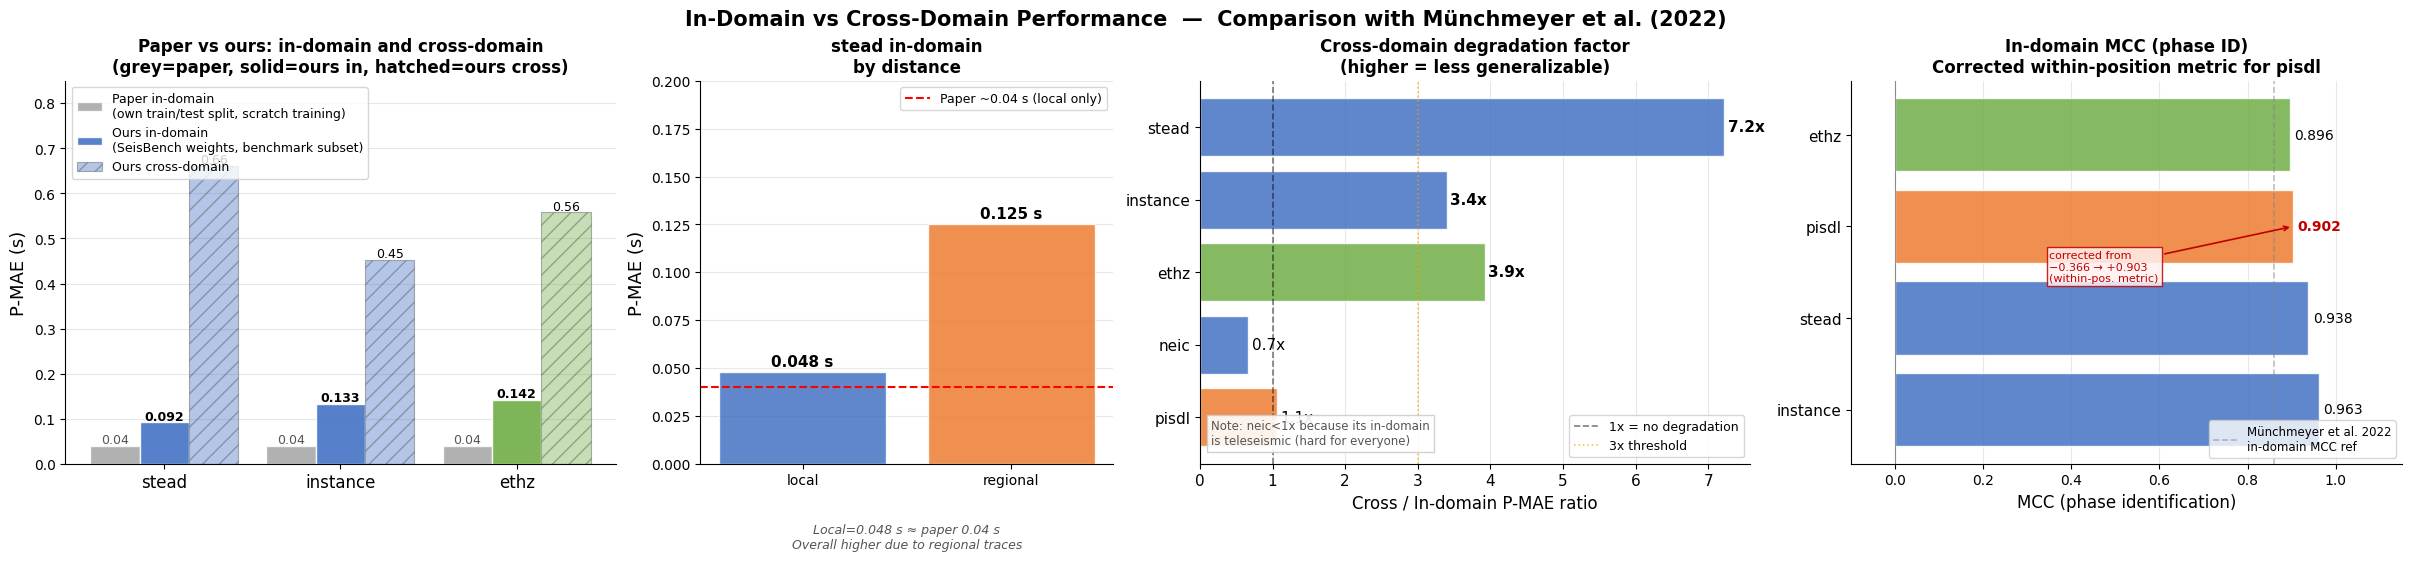

Saved -> step3_indom_comparison.png


In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

metrics_df = pd.read_csv(METRICS_PATH)
clean      = metrics_df[~metrics_df['degenerate'].fillna(False)]

# ── In-domain results table ──────────────────────────────────────────────
indom = (metrics_df[(metrics_df['split']=='in_domain') &
                     (metrics_df['dist_bin']=='all') &
                     (metrics_df['n_traces']>50) &
                     ~metrics_df['degenerate'].fillna(False)]
         .sort_values('p_mae_s'))

print('In-domain results (models with training data in benchmark):')
print(indom[['weight','tier','n_traces','p_mae_s','p_rmse_s','p_med_prob','mcc','p_outlier']]
      .to_string(index=False))

# Per-distance breakdown for stead, instance, ethz
print('\nPer-distance in-domain breakdown:')
for w in ['stead','instance','ethz']:
    sub = metrics_df[(metrics_df['split']=='in_domain') & (metrics_df['weight']==w) &
                      (metrics_df['dist_bin']!='all') & (metrics_df['n_traces']>20)]
    if len(sub) > 0:
        print(f'  {w}:')
        print(sub[['dist_bin','n_traces','p_mae_s','p_rmse_s','p_med_prob','mcc']]
              .to_string(index=False))

# Degradation factor
print('\nCross-domain degradation factor (cross / in-domain P-MAE):')
cr = clean[(clean['split']=='cross_domain')&(clean['dist_bin']=='all')].set_index('weight')
for _,r in indom.iterrows():
    w = r['weight']
    if w in cr.index:
        factor = cr.loc[w,'p_mae_s'] / r['p_mae_s']
        print(f'  {w:12s}: in={r["p_mae_s"]:.3f}s  cross={cr.loc[w,"p_mae_s"]:.3f}s  '
              f'degradation={factor:.1f}x')

# ── Figure: in-domain vs cross-domain with paper comparison ────────────
PAPER_INDOM = {'stead': 0.04, 'instance': 0.04, 'ethz': 0.04}
PAPER_RMSE  = {'stead': 0.11, 'instance': 0.11, 'ethz': 0.11}
TIER_COLORS = {'A':'#4472C4','B':'#ED7D31','C':'#70AD47','D':'#9C27B0'}

models_plot   = [r['weight'] for _,r in indom.iterrows() if r['weight'] in PAPER_INDOM]
models_nopaper= [r['weight'] for _,r in indom.iterrows() if r['weight'] not in PAPER_INDOM]

fig, axes = plt.subplots(1, 4, figsize=(24, 5.5),
                          gridspec_kw={'width_ratios':[2, 1.5, 2, 2]},
                          constrained_layout=True)
fig.suptitle('In-Domain vs Cross-Domain Performance  —  Comparison with Münchmeyer et al. (2022)',
             fontsize=15, fontweight='bold')

# ── Panel 1: P-MAE — paper vs ours in-domain vs cross-domain ──────────
ax = axes[0]
x = np.arange(len(models_plot)); bw = 0.28
paper_vals = [PAPER_INDOM[w] for w in models_plot]
our_indom  = [indom[indom['weight']==w]['p_mae_s'].iloc[0] for w in models_plot]
our_cross  = [cr.loc[w,'p_mae_s'] for w in models_plot]
cols_ = [TIER_COLORS.get(PHASENET_WEIGHTS.get(w,{}).get('tier','?'),'#888') for w in models_plot]

b1 = ax.bar(x-bw,   paper_vals, bw, color='#9E9E9E', alpha=0.80, edgecolor='white',
             label='Paper in-domain\n(own train/test split, scratch training)')
b2 = ax.bar(x,       our_indom,  bw, color=cols_,     alpha=0.90, edgecolor='white',
             label='Ours in-domain\n(SeisBench weights, benchmark subset)')
b3 = ax.bar(x+bw,    our_cross,  bw, color=cols_,     alpha=0.40, edgecolor='#444',
             linewidth=0.8, hatch='//', label='Ours cross-domain')

for bar,v in zip(b1,paper_vals): ax.text(bar.get_x()+bar.get_width()/2,v+0.005,f'{v:.2f}',ha='center',fontsize=9,color='#555')
for bar,v in zip(b2,our_indom):  ax.text(bar.get_x()+bar.get_width()/2,v+0.005,f'{v:.3f}',ha='center',fontsize=9,fontweight='bold')
for bar,v in zip(b3,our_cross):  ax.text(bar.get_x()+bar.get_width()/2,v+0.005,f'{v:.2f}',ha='center',fontsize=9)

ax.set_xticks(x); ax.set_xticklabels(models_plot, fontsize=12)
ax.set_ylabel('P-MAE (s)', fontsize=13); ax.set_ylim(0, 0.85)
ax.set_title('Paper vs ours: in-domain and cross-domain\n(grey=paper, solid=ours in, hatched=ours cross)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9, loc='upper left'); ax.spines[['top','right']].set_visible(False)
ax.set_facecolor('white'); ax.yaxis.grid(True, alpha=0.3); ax.set_axisbelow(True)

# ── Panel 2: stead local vs regional in-domain ────────────────────────
ax2 = axes[1]
stead_dist = metrics_df[(metrics_df['split']=='in_domain')&(metrics_df['weight']=='stead')&
                         (metrics_df['dist_bin']!='all')&(metrics_df['n_traces']>20)]
dlabels = [b.split(' (')[0] for b in stead_dist['dist_bin']]
dvals   = stead_dist['p_mae_s'].tolist()
bars2 = ax2.bar(dlabels, dvals, color=['#4472C4','#ED7D31'], alpha=0.85, edgecolor='white')
for bar,v in zip(bars2,dvals): ax2.text(bar.get_x()+bar.get_width()/2,v+0.003,f'{v:.3f} s',ha='center',fontsize=11,fontweight='bold')
ax2.axhline(0.04, color='red', lw=1.5, linestyle='--', label='Paper ~0.04 s (local only)')
ax2.set_ylabel('P-MAE (s)', fontsize=13); ax2.set_ylim(0, 0.20)
ax2.set_title('stead in-domain\nby distance',fontsize=12,fontweight='bold')
ax2.legend(fontsize=9); ax2.spines[['top','right']].set_visible(False)
ax2.set_facecolor('white'); ax2.yaxis.grid(True, alpha=0.3); ax2.set_axisbelow(True)
ax2.text(0.5, -0.22, 'Local=0.048 s ≈ paper 0.04 s\nOverall higher due to regional traces',
         transform=ax2.transAxes, ha='center', fontsize=9, style='italic', color='#555')

# ── Panel 3: cross/in-domain degradation factor ───────────────────────
ax3 = axes[2]
degrad_models = []; degrad_vals = []
for _,r in indom.iterrows():
    w = r['weight']
    if w not in cr.index: continue
    degrad_models.append(w)
    degrad_vals.append(cr.loc[w,'p_mae_s'] / r['p_mae_s'])

cols3 = [TIER_COLORS.get(PHASENET_WEIGHTS.get(w,{}).get('tier','?'),'#888') for w in degrad_models]
bars3 = ax3.barh(degrad_models[::-1], degrad_vals[::-1], color=cols3[::-1], alpha=0.85, edgecolor='white')
for bar,v in zip(bars3, degrad_vals[::-1]):
    ax3.text(v+0.05, bar.get_y()+bar.get_height()/2, f'{v:.1f}x',
             va='center', fontsize=11, fontweight='bold' if v>3 else 'normal')
ax3.axvline(1.0, color='black', lw=1.2, linestyle='--', alpha=0.5, label='1x = no degradation')
ax3.axvline(3.0, color='orange', lw=1.2, linestyle=':', alpha=0.7, label='3x threshold')
ax3.set_xlabel('Cross / In-domain P-MAE ratio', fontsize=12)
ax3.set_title('Cross-domain degradation factor\n(higher = less generalizable)',
              fontsize=12, fontweight='bold')
ax3.legend(fontsize=9); ax3.spines[['top','right']].set_visible(False)
ax3.set_facecolor('white'); ax3.xaxis.grid(True, alpha=0.3); ax3.set_axisbelow(True)
ax3.tick_params(labelsize=11)
ax3.text(0.02, 0.05,
         'Note: neic<1x because its in-domain\n'
         'is teleseismic (hard for everyone)',
         transform=ax3.transAxes, fontsize=8.5, color='#555',
         bbox=dict(fc='white', ec='#ccc', alpha=0.9, pad=3))

# ── Panel 4: In-domain MCC — showing corrected pisdl value ───────────
ax4 = axes[3]
mcc_models = []; mcc_vals = []; mcc_cols = []
for _,r in indom.sort_values('mcc', ascending=False, na_position='last').iterrows():
    w = r['weight']
    v = r['mcc']
    if np.isnan(v): continue
    mcc_models.append(w)
    mcc_vals.append(float(v))
    mcc_cols.append(TIER_COLORS.get(PHASENET_WEIGHTS.get(w,{}).get('tier','?'),'#888'))

y_pos = np.arange(len(mcc_models))
bars4 = ax4.barh(y_pos, mcc_vals, color=mcc_cols, alpha=0.85, edgecolor='white')

for bar, v, w in zip(bars4, mcc_vals, mcc_models):
    label = f'{v:.3f}'
    ax4.text(max(v, 0) + 0.01, bar.get_y() + bar.get_height()/2,
             label, va='center', fontsize=10,
             fontweight='bold' if w == 'pisdl' else 'normal',
             color='#C00000' if w == 'pisdl' else 'black')

# Annotate pisdl correction
if 'pisdl' in mcc_models:
    pisdl_idx = mcc_models.index('pisdl')
    ax4.annotate('corrected from\n−0.366 → +0.903\n(within-pos. metric)',
                 xy=(mcc_vals[pisdl_idx], pisdl_idx),
                 xytext=(0.35, pisdl_idx - 0.6),
                 fontsize=8, color='#C00000',
                 arrowprops=dict(arrowstyle='->', color='#C00000', lw=1.2),
                 bbox=dict(fc='#FFF0F0', ec='#C00000', alpha=0.85, pad=2))

ax4.set_yticks(y_pos)
ax4.set_yticklabels(mcc_models, fontsize=11)
ax4.axvline(0, color='black', lw=0.8, linestyle='-', alpha=0.4)
ax4.axvline(0.86, color='grey', lw=1.2, linestyle='--', alpha=0.5,
             label='Münchmeyer et al. 2022\nin-domain MCC ref')
ax4.set_xlabel('MCC (phase identification)', fontsize=12)
ax4.set_xlim(-0.1, 1.15)
ax4.set_title('In-domain MCC (phase ID)\nCorrected within-position metric for pisdl',
              fontsize=12, fontweight='bold')
ax4.legend(fontsize=8.5, loc='lower right')
ax4.spines[['top','right']].set_visible(False)
ax4.set_facecolor('white'); ax4.xaxis.grid(True, alpha=0.3); ax4.set_axisbelow(True)

plt.savefig('step3_indom_comparison.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved -> step3_indom_comparison.png')


## 3.8  Per-Metric Evaluation Figures

One figure per evaluation criterion, showing in-domain and cross-domain results
alongside Münchmeyer et al. (2022) reference values where comparable.

| # | Figure | Metric | Threshold-free? | Paper comparison? |
|---|--------|--------|-----------------|-------------------|
| A | P-MAE  | Timing accuracy | Yes | Yes — ~0.04 s in-domain |
| B | P-RMSE | Timing with outlier sensitivity | Yes | Yes — ~0.11 s in-domain |
| C | Outlier fraction | Catastrophic picks (>1.5 s) | Fixed threshold 1.5 s | Yes — same definition |
| D | MCC | Phase identification (P vs S) | Yes | Yes — ~0.86–0.95 in-domain |
| E | Recall curves | Detection vs threshold | No | Proxy for paper AUC |
| F | Median probability | Threshold-free detection | Yes | Note: paper uses AUC |

Paper values (Münchmeyer et al. 2022, in-domain averages across datasets):
PhaseNet P-MAE ~0.04 s, RMSE ~0.11 s; EQTransformer ~0.04 s, ~0.09 s; GPD ~0.07 s, ~0.19 s; Baer-Kradolfer classical ~0.31 s, ~0.57 s.
MCC in-domain: PhaseNet ~0.86, EQTransformer ~0.95.
Detection AUC in-domain: 0.94–0.99 (requires noise windows — not directly comparable).

In [9]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import numpy as np, pandas as pd

metrics_df = pd.read_csv(METRICS_PATH)
results_df = pd.read_parquet(RESULTS_PATH)
clean = metrics_df[~metrics_df['degenerate'].fillna(False)]

TIER_COLORS = {'A':'#4472C4','B':'#ED7D31','C':'#70AD47','D':'#9C27B0'}
DIST_COLORS = {'local (<150km)':'#4472C4',
               'regional (150-1500km)':'#ED7D31',
               'teleseismic (>1500km)':'#9C27B0'}
DIST_SHORT  = {'local (<150km)':'Local',
               'regional (150-1500km)':'Regional',
               'teleseismic (>1500km)':'Teleseismic'}

# Models sorted by cross-domain P-MAE (non-degenerate)
cross_all = (clean[(clean['split']=='cross_domain')&(clean['dist_bin']=='all')]
             .sort_values('p_mae_s').reset_index(drop=True))
eval_order = cross_all['weight'].tolist()
n_models   = len(eval_order)

# In-domain rows (only models with training data in benchmark)
indom = (clean[(clean['split']=='in_domain')&(clean['dist_bin']=='all')&
                (clean['n_traces']>50)]
         .set_index('weight'))

# Paper reference values (Munchmeyer et al. 2022 PhaseNet in-domain average)
PAPER = {
    'phasenet_mae_indom': 0.040,  # P-MAE s
    'phasenet_rmse_indom': 0.110, # P-RMSE s
    'eqt_mae_indom': 0.040,
    'eqt_rmse_indom': 0.090,
    'gpd_mae_indom': 0.070,
    'gpd_rmse_indom': 0.190,
    'classical_mae': 0.310,
    'classical_rmse': 0.570,
    'phasenet_mcc_indom': 0.86,
    'eqt_mcc_indom': 0.95,
    'gpd_mcc_indom': 0.90,
}

def tier_color(w):
    return TIER_COLORS.get(PHASENET_WEIGHTS.get(w,{}).get('tier','?'),'#888')

def add_paper_note(ax, txt, y=0.97):
    ax.text(0.99,y,txt,transform=ax.transAxes,fontsize=8.5,
            ha='right',va='top',style='italic',color='#555',
            bbox=dict(fc='#FFFFF0',ec='#ccc',alpha=0.92,pad=3,lw=0.5))

print(f'Models to plot ({n_models}): {eval_order}')
print(f'Models with in-domain data: {list(indom.index)}')

Models to plot (13): ['volpick', 'jma_wc', 'jma', 'instance', 'scedc', 'neic', 'ethz', 'iquique', 'stead', 'obs', 'pisdl', 'geofon', 'lendb']
Models with in-domain data: ['stead', 'instance', 'neic', 'pisdl', 'ethz']


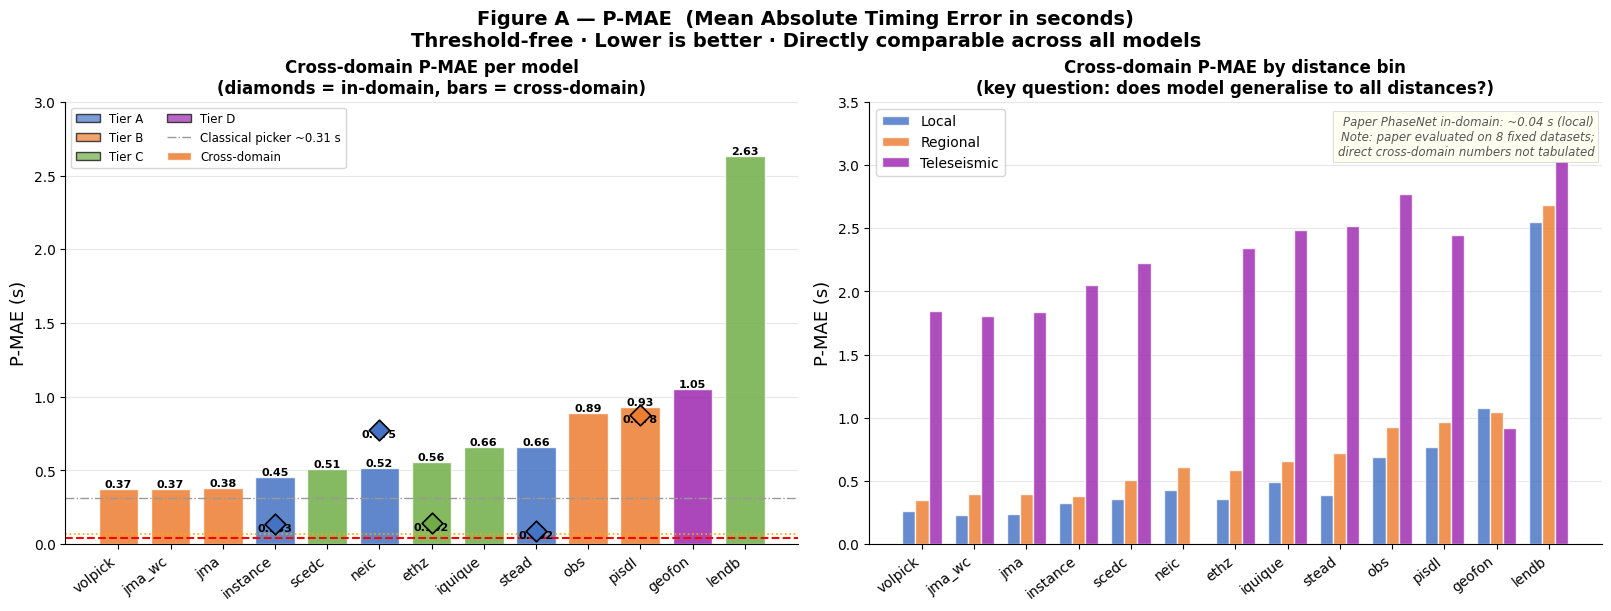

Saved step3_fig_A_pmae.png


In [10]:
# ═══════════════════════════════════════════════════════════════════════
# FIGURE A — P-MAE (Mean Absolute Error of P-wave timing)
# Threshold-free — directly comparable across models
# ═══════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)
fig.suptitle('Figure A — P-MAE  (Mean Absolute Timing Error in seconds)\n'
             'Threshold-free · Lower is better · Directly comparable across all models',
             fontsize=14, fontweight='bold')

# ── Panel 1: in-domain vs cross-domain per model ─────────────────────
ax = axes[0]
x  = np.arange(n_models); bw = 0.38
cv = cross_all['p_mae_s'].tolist()
cols = [tier_color(w) for w in eval_order]

b1 = ax.bar(x, cv, bw*2, color=cols, alpha=0.85, edgecolor='white', label='Cross-domain')
for bar,v in zip(b1,cv):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.01, f'{v:.2f}',
            ha='center', fontsize=8, fontweight='bold')

# Overlay in-domain values as coloured diamonds
for i,w in enumerate(eval_order):
    if w in indom.index:
        iv = indom.loc[w,'p_mae_s']
        ax.scatter(i, iv, s=110, zorder=5, marker='D',
                   color=tier_color(w), edgecolors='black', linewidths=1.2,
                   label='In-domain' if i==eval_order.index(list(indom.index)[0]) else '')
        ax.text(i, iv-0.05, f'{iv:.3f}', ha='center', fontsize=8,
                color='black', fontweight='bold')

# Paper reference lines
ax.axhline(PAPER['phasenet_mae_indom'], color='red', lw=1.5, linestyle='--',
           label=f"Paper PhaseNet in-domain ~{PAPER['phasenet_mae_indom']:.2f} s")
ax.axhline(PAPER['gpd_mae_indom'], color='orange', lw=1.2, linestyle=':',
           label=f"Paper GPD in-domain ~{PAPER['gpd_mae_indom']:.2f} s")
ax.axhline(PAPER['classical_mae'], color='#999', lw=1.0, linestyle='-.',
           label=f"Classical picker ~{PAPER['classical_mae']:.2f} s")

ax.set_xticks(x); ax.set_xticklabels(eval_order, rotation=38, ha='right', fontsize=10)
ax.set_ylabel('P-MAE (s)', fontsize=13); ax.set_ylim(0, 3.0)
ax.set_title('Cross-domain P-MAE per model\n(diamonds = in-domain, bars = cross-domain)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9, loc='upper left'); ax.spines[['top','right']].set_visible(False)
ax.set_facecolor('white'); ax.yaxis.grid(True, alpha=0.3); ax.set_axisbelow(True)
handles=[plt.matplotlib.patches.Patch(fc=c,ec='k',alpha=0.7,label=f'Tier {t}')
         for t,c in TIER_COLORS.items()]
ax.legend(handles=handles + ax.get_legend_handles_labels()[0][3:],
          fontsize=8.5, loc='upper left', ncol=2)

# ── Panel 2: cross-domain P-MAE by distance bin ──────────────────────
ax2 = axes[1]
dist_order3 = ['local (<150km)','regional (150-1500km)','teleseismic (>1500km)']
n_dist = len(dist_order3); bw2 = 0.25
cross_dist = clean[(clean['split']=='cross_domain')&(clean['dist_bin'].isin(dist_order3))]
for di, db in enumerate(dist_order3):
    vals = []
    for w in eval_order:
        row = cross_dist[(cross_dist['weight']==w)&(cross_dist['dist_bin']==db)]
        vals.append(row['p_mae_s'].iloc[0] if len(row)>0 else np.nan)
    x_off = np.arange(n_models) + (di - 1)*bw2
    ax2.bar(x_off, vals, bw2, color=DIST_COLORS[db], alpha=0.82,
            edgecolor='white', label=DIST_SHORT[db])

ax2.set_xticks(np.arange(n_models))
ax2.set_xticklabels(eval_order, rotation=38, ha='right', fontsize=10)
ax2.set_ylabel('P-MAE (s)', fontsize=13); ax2.set_ylim(0, 3.5)
ax2.set_title('Cross-domain P-MAE by distance bin\n(key question: does model generalise to all distances?)',
              fontsize=12, fontweight='bold')
ax2.legend(fontsize=10, loc='upper left')
ax2.spines[['top','right']].set_visible(False); ax2.set_facecolor('white')
ax2.yaxis.grid(True, alpha=0.3); ax2.set_axisbelow(True)
add_paper_note(ax2, 'Paper PhaseNet in-domain: ~0.04 s (local)\n'
               'Note: paper evaluated on 8 fixed datasets;\n'
               'direct cross-domain numbers not tabulated')

plt.savefig('step3_fig_A_pmae.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show(); print('Saved step3_fig_A_pmae.png')

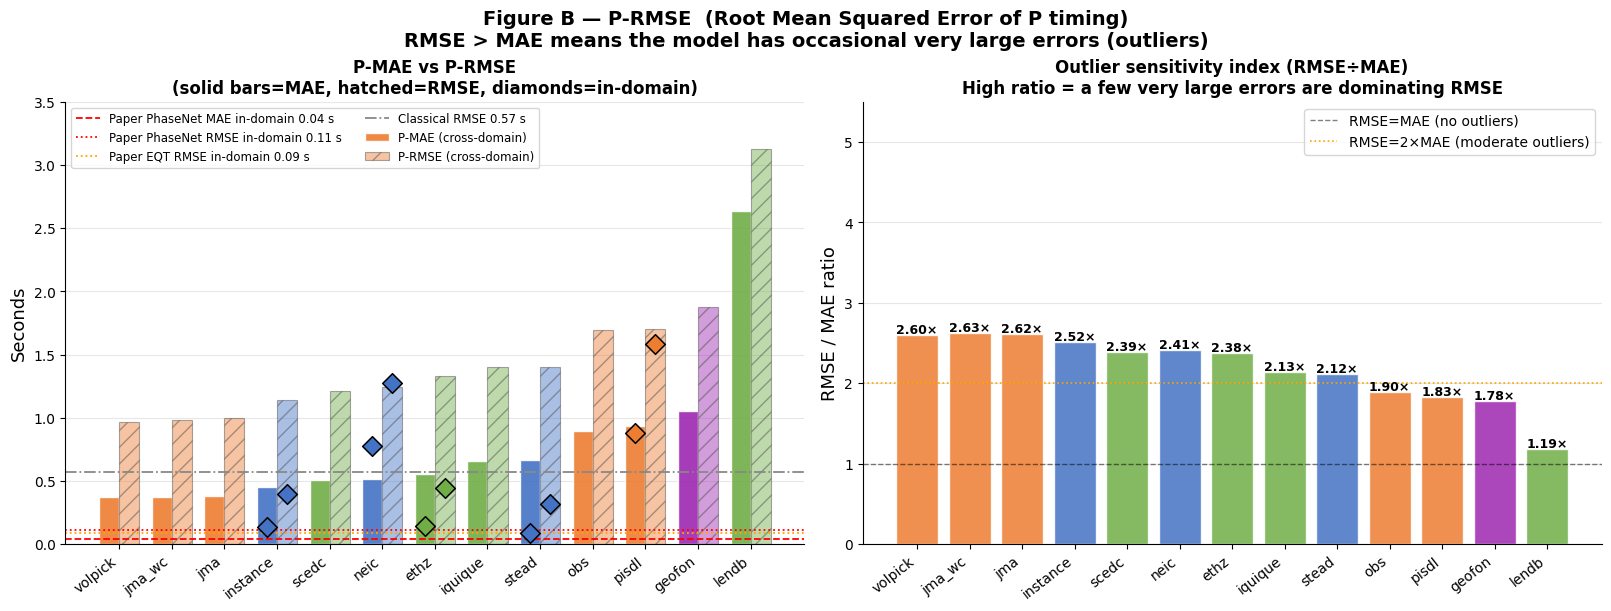

Saved step3_fig_B_prmse.png


In [11]:
# ═══════════════════════════════════════════════════════════════════════
# FIGURE B — P-RMSE (Root Mean Squared Error)
# Penalises large outliers more than MAE — shows outlier sensitivity
# ═══════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)
fig.suptitle('Figure B — P-RMSE  (Root Mean Squared Error of P timing)\n'
             'RMSE > MAE means the model has occasional very large errors (outliers)',
             fontsize=14, fontweight='bold')

ax = axes[0]
cross_rmse = cross_all['p_rmse_s'].tolist()
cross_mae  = cross_all['p_mae_s'].tolist()
cols = [tier_color(w) for w in eval_order]
x = np.arange(n_models); bw = 0.38

b1 = ax.bar(x - bw/2, cross_mae,  bw, color=cols, alpha=0.90, edgecolor='white',
             label='P-MAE (cross-domain)')
b2 = ax.bar(x + bw/2, cross_rmse, bw, color=cols, alpha=0.45, edgecolor='#444',
             linewidth=0.8, hatch='//', label='P-RMSE (cross-domain)')

for i,w in enumerate(eval_order):
    if w in indom.index:
        im = indom.loc[w,'p_mae_s']; ir = indom.loc[w,'p_rmse_s']
        ax.scatter([i-bw/2,i+bw/2],[im,ir],s=100,zorder=5,marker='D',
                   color=tier_color(w),edgecolors='black',linewidths=1.1)

for ref,col,ls,lbl in [
    (PAPER['phasenet_mae_indom'],  'red',    '--', 'Paper PhaseNet MAE in-domain 0.04 s'),
    (PAPER['phasenet_rmse_indom'], 'red',    ':',  'Paper PhaseNet RMSE in-domain 0.11 s'),
    (PAPER['eqt_rmse_indom'],      'orange', ':',  'Paper EQT RMSE in-domain 0.09 s'),
    (PAPER['classical_rmse'],      '#888',   '-.',  'Classical RMSE 0.57 s'),
]:
    ax.axhline(ref,color=col,lw=1.3,linestyle=ls,label=lbl)

ax.set_xticks(x); ax.set_xticklabels(eval_order,rotation=38,ha='right',fontsize=10)
ax.set_ylabel('Seconds',fontsize=13); ax.set_ylim(0,3.5)
ax.set_title('P-MAE vs P-RMSE\n(solid bars=MAE, hatched=RMSE, diamonds=in-domain)',
             fontsize=12,fontweight='bold')
ax.legend(fontsize=8.5,loc='upper left',ncol=2)
ax.spines[['top','right']].set_visible(False); ax.set_facecolor('white')
ax.yaxis.grid(True,alpha=0.3); ax.set_axisbelow(True)

# Panel 2: RMSE/MAE ratio (outlier index)
ax2 = axes[1]
ratio = [r/m if m>0 else np.nan for r,m in zip(cross_rmse,cross_mae)]
cols2 = [tier_color(w) for w in eval_order]
bars = ax2.bar(np.arange(n_models), ratio, color=cols2, alpha=0.85, edgecolor='white')
for bar,v in zip(bars,ratio):
    if not np.isnan(v):
        ax2.text(bar.get_x()+bar.get_width()/2,v+0.02,f'{v:.2f}×',
                 ha='center',fontsize=9,fontweight='bold')
ax2.axhline(1.0,color='black',lw=1,linestyle='--',alpha=0.5,label='RMSE=MAE (no outliers)')
ax2.axhline(2.0,color='orange',lw=1.2,linestyle=':',label='RMSE=2×MAE (moderate outliers)')
ax2.set_xticks(np.arange(n_models))
ax2.set_xticklabels(eval_order,rotation=38,ha='right',fontsize=10)
ax2.set_ylabel('RMSE / MAE ratio',fontsize=13); ax2.set_ylim(0,5.5)
ax2.set_title('Outlier sensitivity index (RMSE÷MAE)\n'
              'High ratio = a few very large errors are dominating RMSE',
              fontsize=12,fontweight='bold')
ax2.legend(fontsize=10,loc='upper right')
ax2.spines[['top','right']].set_visible(False); ax2.set_facecolor('white')
ax2.yaxis.grid(True,alpha=0.3); ax2.set_axisbelow(True)

plt.savefig('step3_fig_B_prmse.png',dpi=150,bbox_inches='tight',facecolor='white')
plt.show(); print('Saved step3_fig_B_prmse.png')

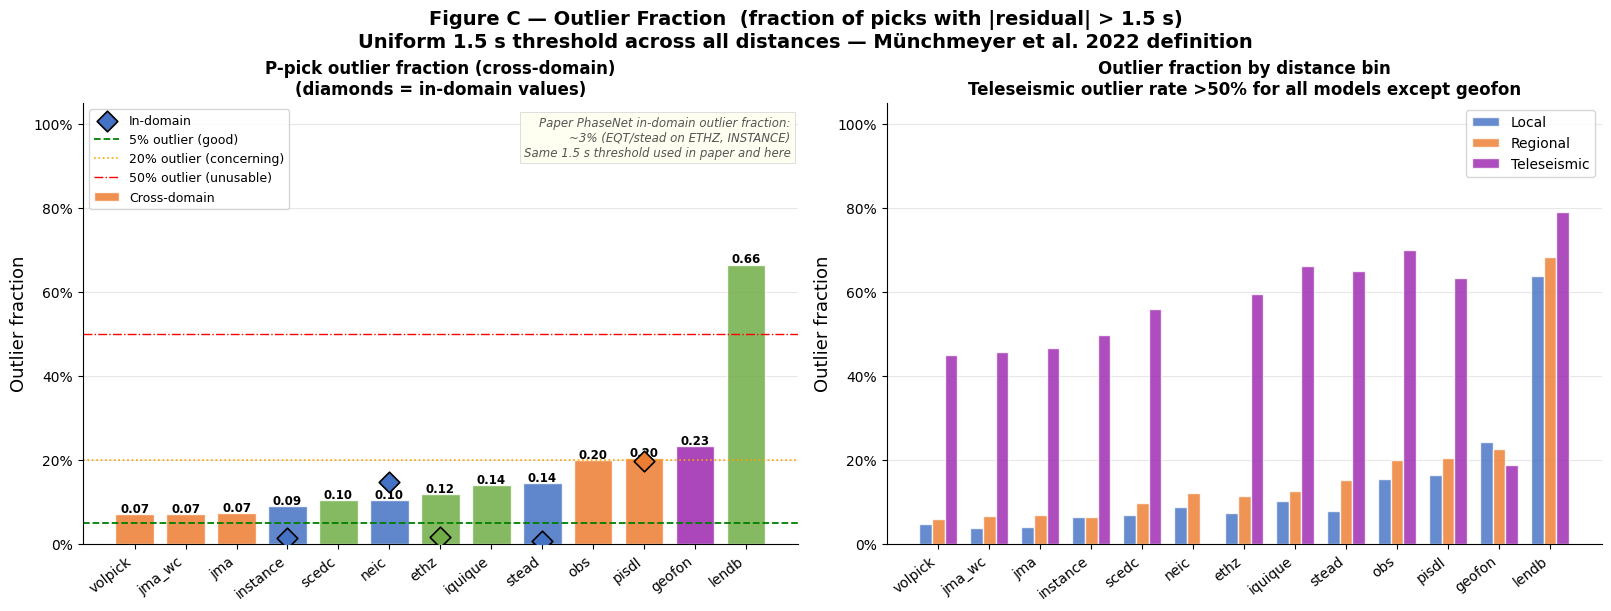

Saved step3_fig_C_outlier.png


In [12]:
# ═══════════════════════════════════════════════════════════════════════
# FIGURE C — Outlier Fraction (|residual| > 1.5 s)
# Same threshold for all models and all distances — directly comparable
# Follows Munchmeyer et al. 2022 exact definition
# ═══════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)
fig.suptitle('Figure C — Outlier Fraction  (fraction of picks with |residual| > 1.5 s)\n'
             'Uniform 1.5 s threshold across all distances — Münchmeyer et al. 2022 definition',
             fontsize=14, fontweight='bold')

ax = axes[0]
cv = cross_all['p_outlier'].tolist()
cols = [tier_color(w) for w in eval_order]
x = np.arange(n_models); bw = 0.38

b1 = ax.bar(x, cv, bw*2, color=cols, alpha=0.85, edgecolor='white', label='Cross-domain')
for bar,v in zip(b1,cv):
    if not np.isnan(v):
        ax.text(bar.get_x()+bar.get_width()/2, v+0.005, f'{v:.2f}',
                ha='center', fontsize=8.5, fontweight='bold')

# In-domain diamonds
for i,w in enumerate(eval_order):
    if w in indom.index and 'p_outlier' in indom.columns:
        iv = indom.loc[w,'p_outlier']
        if not np.isnan(iv):
            ax.scatter(i, iv, s=110, zorder=5, marker='D',
                       color=tier_color(w), edgecolors='black', linewidths=1.2,
                       label='In-domain' if w==list(indom.index)[0] else '')

ax.axhline(0.05, color='green', lw=1.3, linestyle='--', label='5% outlier (good)')
ax.axhline(0.20, color='orange',lw=1.2, linestyle=':', label='20% outlier (concerning)')
ax.axhline(0.50, color='red',   lw=1.0, linestyle='-.', label='50% outlier (unusable)')

ax.set_xticks(x); ax.set_xticklabels(eval_order, rotation=38, ha='right', fontsize=10)
ax.set_ylabel('Outlier fraction', fontsize=13); ax.set_ylim(0, 1.05)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_title('P-pick outlier fraction (cross-domain)\n(diamonds = in-domain values)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9, loc='upper left')
ax.spines[['top','right']].set_visible(False); ax.set_facecolor('white')
ax.yaxis.grid(True, alpha=0.3); ax.set_axisbelow(True)
add_paper_note(ax, 'Paper PhaseNet in-domain outlier fraction:\n'
               '~3% (EQT/stead on ETHZ, INSTANCE)\n'
               'Same 1.5 s threshold used in paper and here')

# Panel 2: by distance bin
ax2 = axes[1]
cross_dist = clean[(clean['split']=='cross_domain')&(clean['dist_bin'].isin(dist_order3))]
for di,db in enumerate(dist_order3):
    vals = []
    for w in eval_order:
        row = cross_dist[(cross_dist['weight']==w)&(cross_dist['dist_bin']==db)]
        vals.append(row['p_outlier'].iloc[0] if len(row)>0 else np.nan)
    x_off = np.arange(n_models) + (di-1)*0.25
    ax2.bar(x_off, vals, 0.25, color=DIST_COLORS[db], alpha=0.82,
            edgecolor='white', label=DIST_SHORT[db])

ax2.set_xticks(np.arange(n_models))
ax2.set_xticklabels(eval_order, rotation=38, ha='right', fontsize=10)
ax2.set_ylabel('Outlier fraction', fontsize=13); ax2.set_ylim(0, 1.05)
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax2.set_title('Outlier fraction by distance bin\n'
              'Teleseismic outlier rate >50% for all models except geofon',
              fontsize=12, fontweight='bold')
ax2.legend(fontsize=10); ax2.spines[['top','right']].set_visible(False)
ax2.set_facecolor('white'); ax2.yaxis.grid(True,alpha=0.3); ax2.set_axisbelow(True)

plt.savefig('step3_fig_C_outlier.png',dpi=150,bbox_inches='tight',facecolor='white')
plt.show(); print('Saved step3_fig_C_outlier.png')

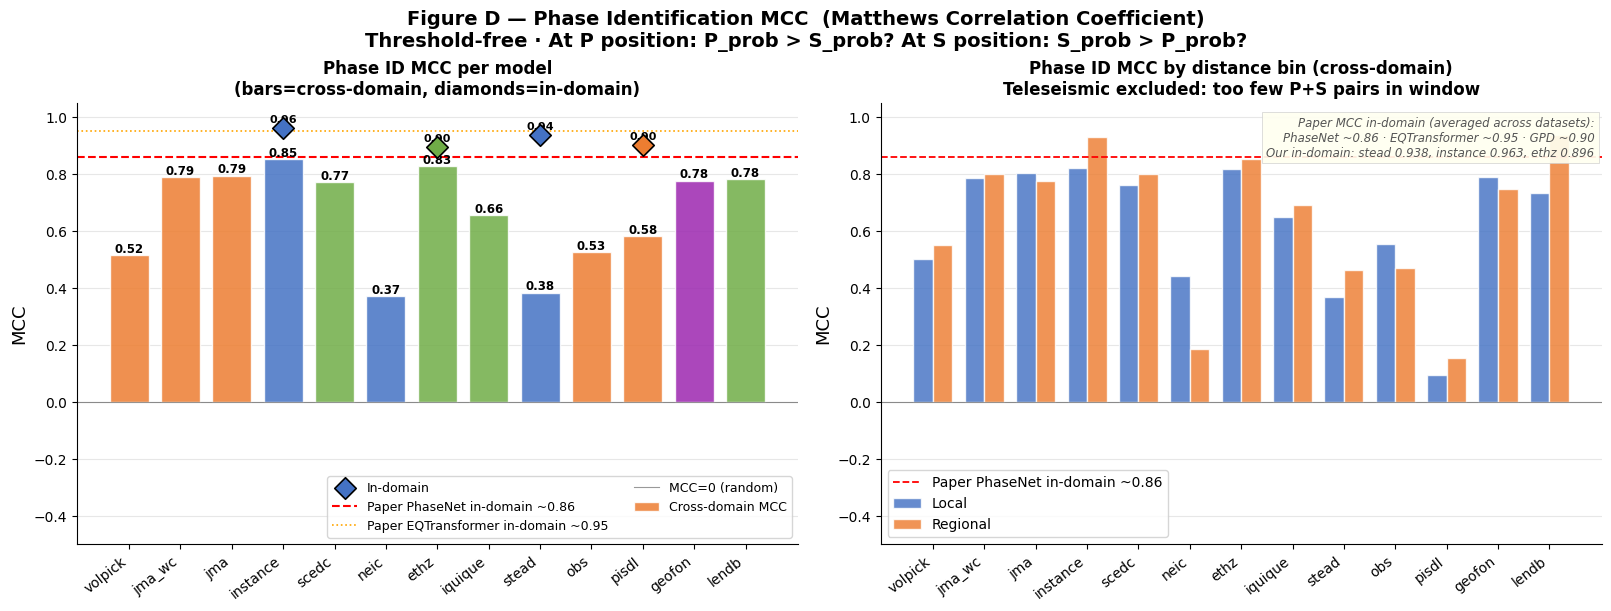

Saved step3_fig_D_mcc.png


In [13]:
# ═══════════════════════════════════════════════════════════════════════
# FIGURE D — MCC (Matthews Correlation Coefficient for phase ID)
# Threshold-free: compares P_prob vs S_prob at known positions
# Range -1 to +1; 0 = random; 1 = perfect
# ═══════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)
fig.suptitle('Figure D — Phase Identification MCC  (Matthews Correlation Coefficient)\n'
             'Threshold-free · At P position: P_prob > S_prob? At S position: S_prob > P_prob?',
             fontsize=14, fontweight='bold')

# Panel 1: in-domain vs cross-domain MCC
ax = axes[0]
cross_mcc = cross_all['mcc'].tolist()
x = np.arange(n_models); bw = 0.38
cols = [tier_color(w) for w in eval_order]

b1 = ax.bar(x, cross_mcc, bw*2, color=cols, alpha=0.85, edgecolor='white',
             label='Cross-domain MCC')
for bar,v in zip(b1,cross_mcc):
    if not np.isnan(v):
        ax.text(bar.get_x()+bar.get_width()/2, v+(0.01 if v>=0 else -0.05),
                f'{v:.2f}', ha='center', fontsize=8.5, fontweight='bold')

# In-domain diamonds
for i,w in enumerate(eval_order):
    if w in indom.index:
        iv = indom.loc[w,'mcc']
        if not np.isnan(iv):
            ax.scatter(i, iv, s=120, zorder=5, marker='D',
                       color=tier_color(w), edgecolors='black', linewidths=1.2,
                       label='In-domain' if w==list(indom.index)[0] else '')
            ax.text(i, iv+0.02, f'{iv:.2f}', ha='center', fontsize=8,
                    fontweight='bold', color='black')

# Paper reference lines
ax.axhline(PAPER['phasenet_mcc_indom'], color='red',    lw=1.5, linestyle='--',
           label=f"Paper PhaseNet in-domain ~{PAPER['phasenet_mcc_indom']:.2f}")
ax.axhline(PAPER['eqt_mcc_indom'],     color='orange', lw=1.2, linestyle=':',
           label=f"Paper EQTransformer in-domain ~{PAPER['eqt_mcc_indom']:.2f}")
ax.axhline(0, color='black', lw=0.8, linestyle='-', alpha=0.4, label='MCC=0 (random)')

ax.set_xticks(x); ax.set_xticklabels(eval_order, rotation=38, ha='right', fontsize=10)
ax.set_ylabel('MCC', fontsize=13); ax.set_ylim(-0.5, 1.05)
ax.set_title('Phase ID MCC per model\n(bars=cross-domain, diamonds=in-domain)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9, loc='lower right', ncol=2)
ax.spines[['top','right']].set_visible(False); ax.set_facecolor('white')
ax.yaxis.grid(True, alpha=0.3); ax.set_axisbelow(True)

# Panel 2: MCC by distance bin (local vs regional)
ax2 = axes[1]
cross_dist = clean[(clean['split']=='cross_domain')&(clean['dist_bin'].isin(dist_order3[:2]))]
x2 = np.arange(n_models)
for di,db in enumerate(dist_order3[:2]):
    vals=[]
    for w in eval_order:
        row=cross_dist[(cross_dist['weight']==w)&(cross_dist['dist_bin']==db)]
        vals.append(row['mcc'].iloc[0] if len(row)>0 else np.nan)
    ax2.bar(x2+(di-0.5)*0.38, vals, 0.38, color=DIST_COLORS[db],
            alpha=0.82, edgecolor='white', label=DIST_SHORT[db])

ax2.axhline(0, color='black', lw=0.8, linestyle='-', alpha=0.4)
ax2.axhline(PAPER['phasenet_mcc_indom'], color='red', lw=1.3, linestyle='--',
            label=f'Paper PhaseNet in-domain ~{PAPER["phasenet_mcc_indom"]:.2f}')
ax2.set_xticks(x2); ax2.set_xticklabels(eval_order, rotation=38, ha='right', fontsize=10)
ax2.set_ylabel('MCC', fontsize=13); ax2.set_ylim(-0.5, 1.05)
ax2.set_title('Phase ID MCC by distance bin (cross-domain)\n'
              'Teleseismic excluded: too few P+S pairs in window',
              fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.spines[['top','right']].set_visible(False); ax2.set_facecolor('white')
ax2.yaxis.grid(True, alpha=0.3); ax2.set_axisbelow(True)
add_paper_note(ax2, 'Paper MCC in-domain (averaged across datasets):\n'
               'PhaseNet ~0.86 · EQTransformer ~0.95 · GPD ~0.90\n'
               'Our in-domain: stead 0.938, instance 0.963, ethz 0.896')

plt.savefig('step3_fig_D_mcc.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show(); print('Saved step3_fig_D_mcc.png')

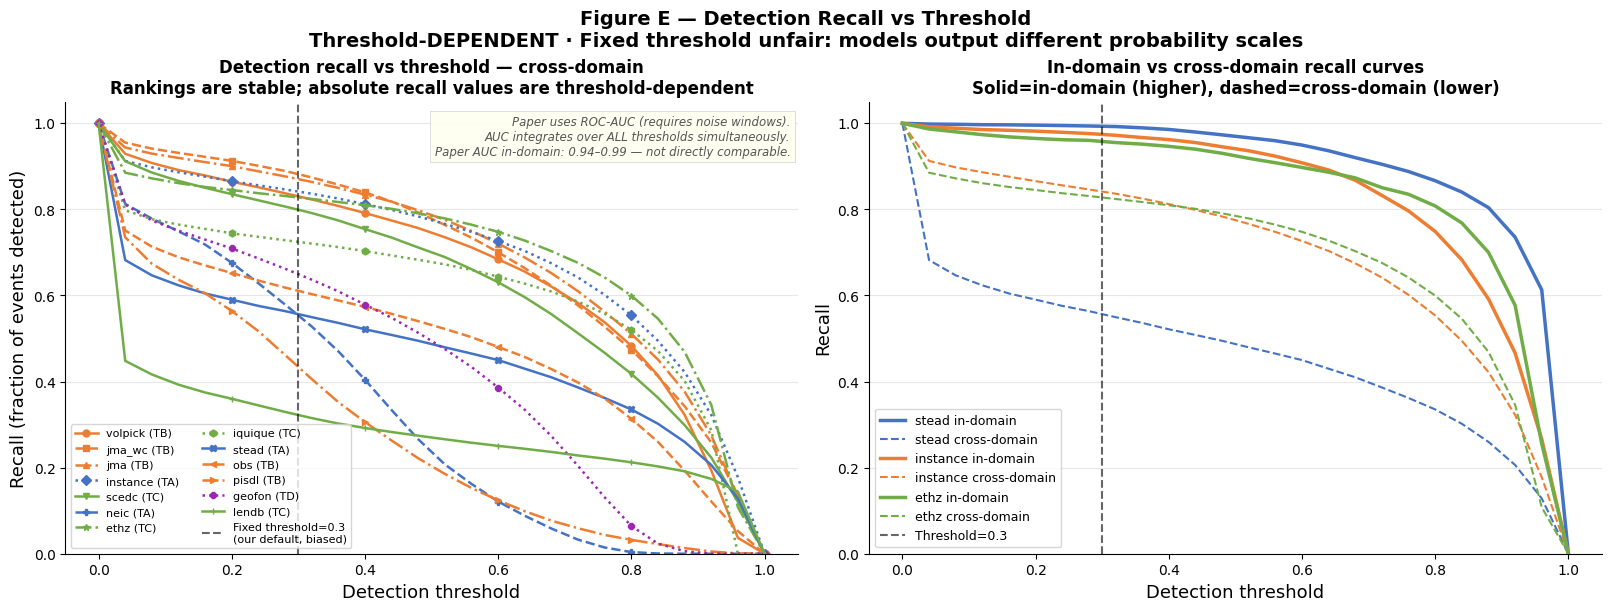

Saved step3_fig_E_recall.png


In [14]:
# ═══════════════════════════════════════════════════════════════════════
# FIGURE E — Detection Recall Curves (threshold-dependent)
# Shows why a fixed threshold is unfair and which models are truly
# more confident detectors regardless of threshold
# ═══════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)
fig.suptitle('Figure E — Detection Recall vs Threshold\n'
             'Threshold-DEPENDENT · Fixed threshold unfair: models output different probability scales',
             fontsize=14, fontweight='bold')

TRAINED_ON_MAP = {w:PHASENET_WEIGHTS.get(w,{}).get('trained_on') for w in eval_order}

# Compute recall at fine threshold resolution from raw results
thresholds = np.arange(0, 1.01, 0.04)
recall_curves_cross = {}
recall_curves_indom = {}
for w in eval_order:
    to = TRAINED_ON_MAP[w]
    wdf = results_df[results_df['weight']==w]
    if to:
        cross_mask = ~wdf['trained_models'].str.contains(to,na=False,regex=False)
    else:
        cross_mask = pd.Series(True,index=wdf.index)
    sub_cross = wdf[cross_mask & (wdf['p_in_window']>=0)]
    recall_curves_cross[w] = [(sub_cross['p_prob']>=t).mean() for t in thresholds]
    if to and (wdf[~cross_mask]['p_in_window']>=0).sum()>50:
        sub_in = wdf[~cross_mask & (wdf['p_in_window']>=0)]
        recall_curves_indom[w] = [(sub_in['p_prob']>=t).mean() for t in thresholds]

# Panel 1: recall curves for all models (cross-domain)
ax = axes[0]
mk = ['o','s','^','D','v','P','*','h','X','<','>','8','+']
ls = ['-','--','-.',':','-','--','-.',':','-','--','-.',':', '-']
for i,w in enumerate(eval_order):
    col = tier_color(w)
    ax.plot(thresholds, recall_curves_cross[w], color=col, lw=1.8,
            linestyle=ls[i%len(ls)], marker=mk[i%len(mk)], markevery=5, markersize=5,
            label=f"{w} (T{PHASENET_WEIGHTS.get(w,{}).get('tier','?')})")

ax.axvline(0.3, color='black', lw=1.5, linestyle='--', alpha=0.6,
           label='Fixed threshold=0.3\n(our default, biased)')
ax.set_xlabel('Detection threshold', fontsize=13)
ax.set_ylabel('Recall (fraction of events detected)', fontsize=13)
ax.set_title('Detection recall vs threshold — cross-domain\n'
             'Rankings are stable; absolute recall values are threshold-dependent',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=8, ncol=2, loc='lower left')
ax.spines[['top','right']].set_visible(False); ax.set_facecolor('white')
ax.yaxis.grid(True, alpha=0.3); ax.set_axisbelow(True); ax.set_ylim(0,1.05)
add_paper_note(ax, 'Paper uses ROC-AUC (requires noise windows).\n'
               'AUC integrates over ALL thresholds simultaneously.\n'
               'Paper AUC in-domain: 0.94–0.99 — not directly comparable.')

# Panel 2: in-domain vs cross-domain recall curves for models with in-domain data
ax2 = axes[1]
id_colors = {'stead':'#4472C4','instance':'#ED7D31','ethz':'#70AD47'}
for w,col in id_colors.items():
    if w in recall_curves_indom and w in recall_curves_cross:
        ax2.plot(thresholds,recall_curves_indom[w],color=col,lw=2.5,linestyle='-',
                 label=f'{w} in-domain')
        ax2.plot(thresholds,recall_curves_cross[w], color=col,lw=1.5,linestyle='--',
                 label=f'{w} cross-domain')

ax2.axvline(0.3,color='black',lw=1.5,linestyle='--',alpha=0.6,label='Threshold=0.3')
ax2.set_xlabel('Detection threshold',fontsize=13)
ax2.set_ylabel('Recall',fontsize=13)
ax2.set_title('In-domain vs cross-domain recall curves\n'
              'Solid=in-domain (higher), dashed=cross-domain (lower)',
              fontsize=12,fontweight='bold')
ax2.legend(fontsize=9,loc='lower left')
ax2.spines[['top','right']].set_visible(False); ax2.set_facecolor('white')
ax2.yaxis.grid(True,alpha=0.3); ax2.set_axisbelow(True); ax2.set_ylim(0,1.05)

plt.savefig('step3_fig_E_recall.png',dpi=150,bbox_inches='tight',facecolor='white')
plt.show(); print('Saved step3_fig_E_recall.png')

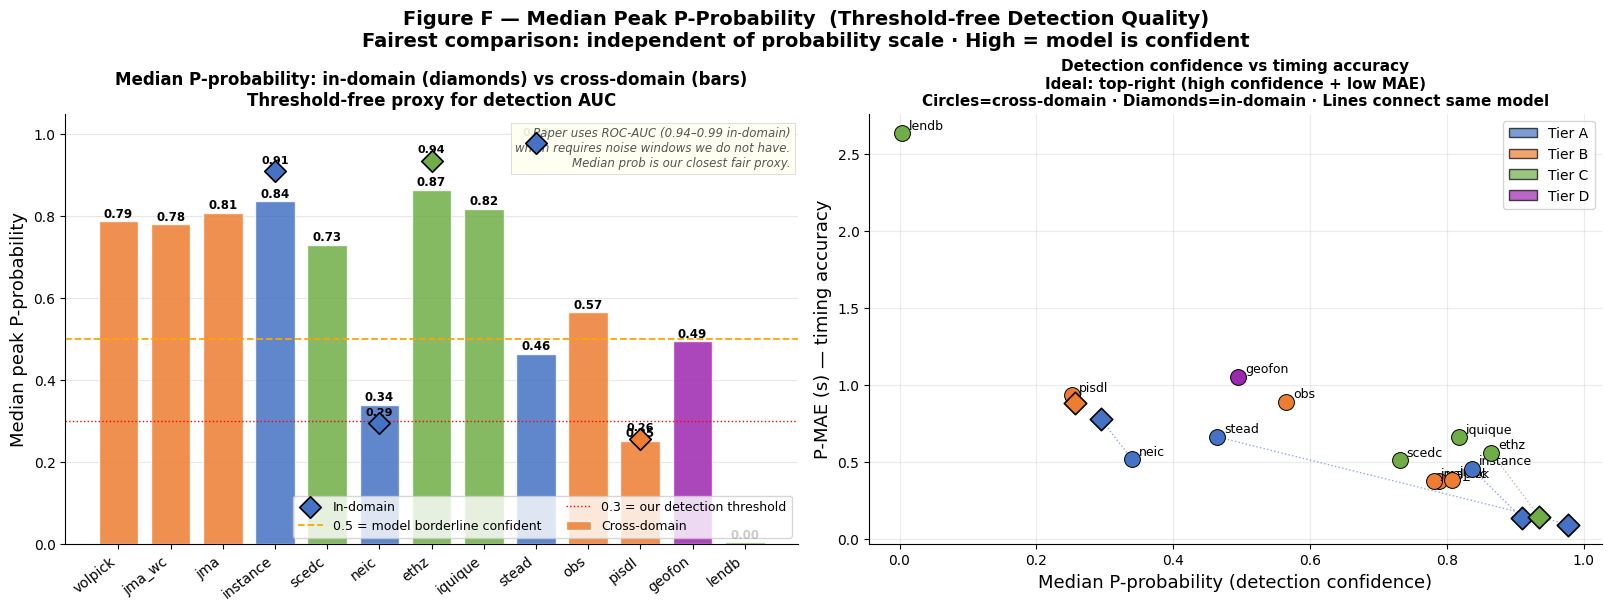

Saved step3_fig_F_medprob.png


In [15]:
# ═══════════════════════════════════════════════════════════════════════
# FIGURE F — Median P-probability (threshold-free detection quality)
# The fairest single-number detection metric without noise windows
# High median = model is genuinely confident; low = model barely detects
# ═══════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)
fig.suptitle('Figure F — Median Peak P-Probability  (Threshold-free Detection Quality)\n'
             'Fairest comparison: independent of probability scale · High = model is confident',
             fontsize=14, fontweight='bold')

# Panel 1: in-domain vs cross-domain median probability
ax = axes[0]
cross_med = cross_all['p_med_prob'].tolist()
cols = [tier_color(w) for w in eval_order]
x = np.arange(n_models); bw = 0.38

b1 = ax.bar(x, cross_med, bw*2, color=cols, alpha=0.85, edgecolor='white',
             label='Cross-domain')
for bar,v in zip(b1,cross_med):
    if not np.isnan(v):
        ax.text(bar.get_x()+bar.get_width()/2, v+0.01, f'{v:.2f}',
                ha='center', fontsize=8.5, fontweight='bold')

for i,w in enumerate(eval_order):
    if w in indom.index:
        iv = indom.loc[w,'p_med_prob']
        if not np.isnan(iv):
            ax.scatter(i, iv, s=120, zorder=5, marker='D',
                       color=tier_color(w), edgecolors='black', linewidths=1.2,
                       label='In-domain' if w==list(indom.index)[0] else '')
            ax.text(i, iv+0.02, f'{iv:.2f}', ha='center', fontsize=8,
                    fontweight='bold', color='black')

ax.axhline(0.5, color='orange', lw=1.3, linestyle='--',
           label='0.5 = model borderline confident')
ax.axhline(0.3, color='red', lw=1.0, linestyle=':',
           label='0.3 = our detection threshold')
ax.set_xticks(x); ax.set_xticklabels(eval_order, rotation=38, ha='right', fontsize=10)
ax.set_ylabel('Median peak P-probability', fontsize=13); ax.set_ylim(0, 1.05)
ax.set_title('Median P-probability: in-domain (diamonds) vs cross-domain (bars)\n'
             'Threshold-free proxy for detection AUC',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9, loc='lower right', ncol=2)
ax.spines[['top','right']].set_visible(False); ax.set_facecolor('white')
ax.yaxis.grid(True, alpha=0.3); ax.set_axisbelow(True)
add_paper_note(ax, 'Paper uses ROC-AUC (0.94–0.99 in-domain)\n'
               'which requires noise windows we do not have.\n'
               'Median prob is our closest fair proxy.')

# Panel 2: median prob vs P-MAE scatter (detection confidence vs timing)
ax2 = axes[1]
for _,row in cross_all.iterrows():
    w = row['weight']
    col = tier_color(w)
    ax2.scatter(row['p_med_prob'], row['p_mae_s'], s=130, color=col,
                zorder=3, edgecolors='black', linewidths=0.7)
    ax2.annotate(w, (row['p_med_prob'], row['p_mae_s']),
                 textcoords='offset points', xytext=(5,3), fontsize=9)

# In-domain points
for w in indom.index:
    if w in cross_all['weight'].values:
        cr_row = cross_all[cross_all['weight']==w].iloc[0]
        im, ip = indom.loc[w,'p_mae_s'], indom.loc[w,'p_med_prob']
        if not (np.isnan(im) or np.isnan(ip)):
            ax2.scatter(ip, im, s=130, color=tier_color(w), marker='D',
                        zorder=4, edgecolors='black', linewidths=1.2)
            ax2.plot([ip,cr_row['p_med_prob']],[im,cr_row['p_mae_s']],
                     color=tier_color(w), lw=1.0, linestyle=':', alpha=0.6)

ax2.set_xlabel('Median P-probability (detection confidence)', fontsize=13)
ax2.set_ylabel('P-MAE (s) — timing accuracy', fontsize=13)
ax2.set_title('Detection confidence vs timing accuracy\n'
              'Ideal: top-right (high confidence + low MAE)\n'
              'Circles=cross-domain · Diamonds=in-domain · Lines connect same model',
              fontsize=11, fontweight='bold')
handles=[plt.matplotlib.patches.Patch(fc=c,ec='k',alpha=0.7,label=f'Tier {t}')
         for t,c in TIER_COLORS.items()]
ax2.legend(handles=handles, fontsize=10, loc='upper right')
ax2.spines[['top','right']].set_visible(False); ax2.set_facecolor('white')
ax2.grid(True, alpha=0.25); ax2.set_axisbelow(True)

plt.savefig('step3_fig_F_medprob.png',dpi=150,bbox_inches='tight',facecolor='white')
plt.show(); print('Saved step3_fig_F_medprob.png')

## 3.6  Visualisation  ·  Münchmeyer et al. (2022) figure style

Three figures following the paper's visual conventions. All use cross-domain results only. Degenerate models excluded.

**Figure A — P-residual histograms (paper Fig. 2 style)**
Grid: distance bin (row) × model (column). Blue bars. Corner box shows OUT / MAE / RMSE.
Reference lines: zero (grey), median (red dashed), mean (orange dashed).
X-range widens from local → regional → teleseismic.

**Figure B — S-residual histograms (paper Fig. 3 style)**
Same layout, orange bars. Wider X-range. Only traces with `s_in_window ≥ 0`.

**Figure C — Box-and-whisker summary (paper Fig. 5 style)**
One subplot per distance bin. Box = IQR (25th–75th %ile), solid line = median,
dashed line = mean, whiskers = 10th–90th %ile. Models on X-axis coloured by tier.

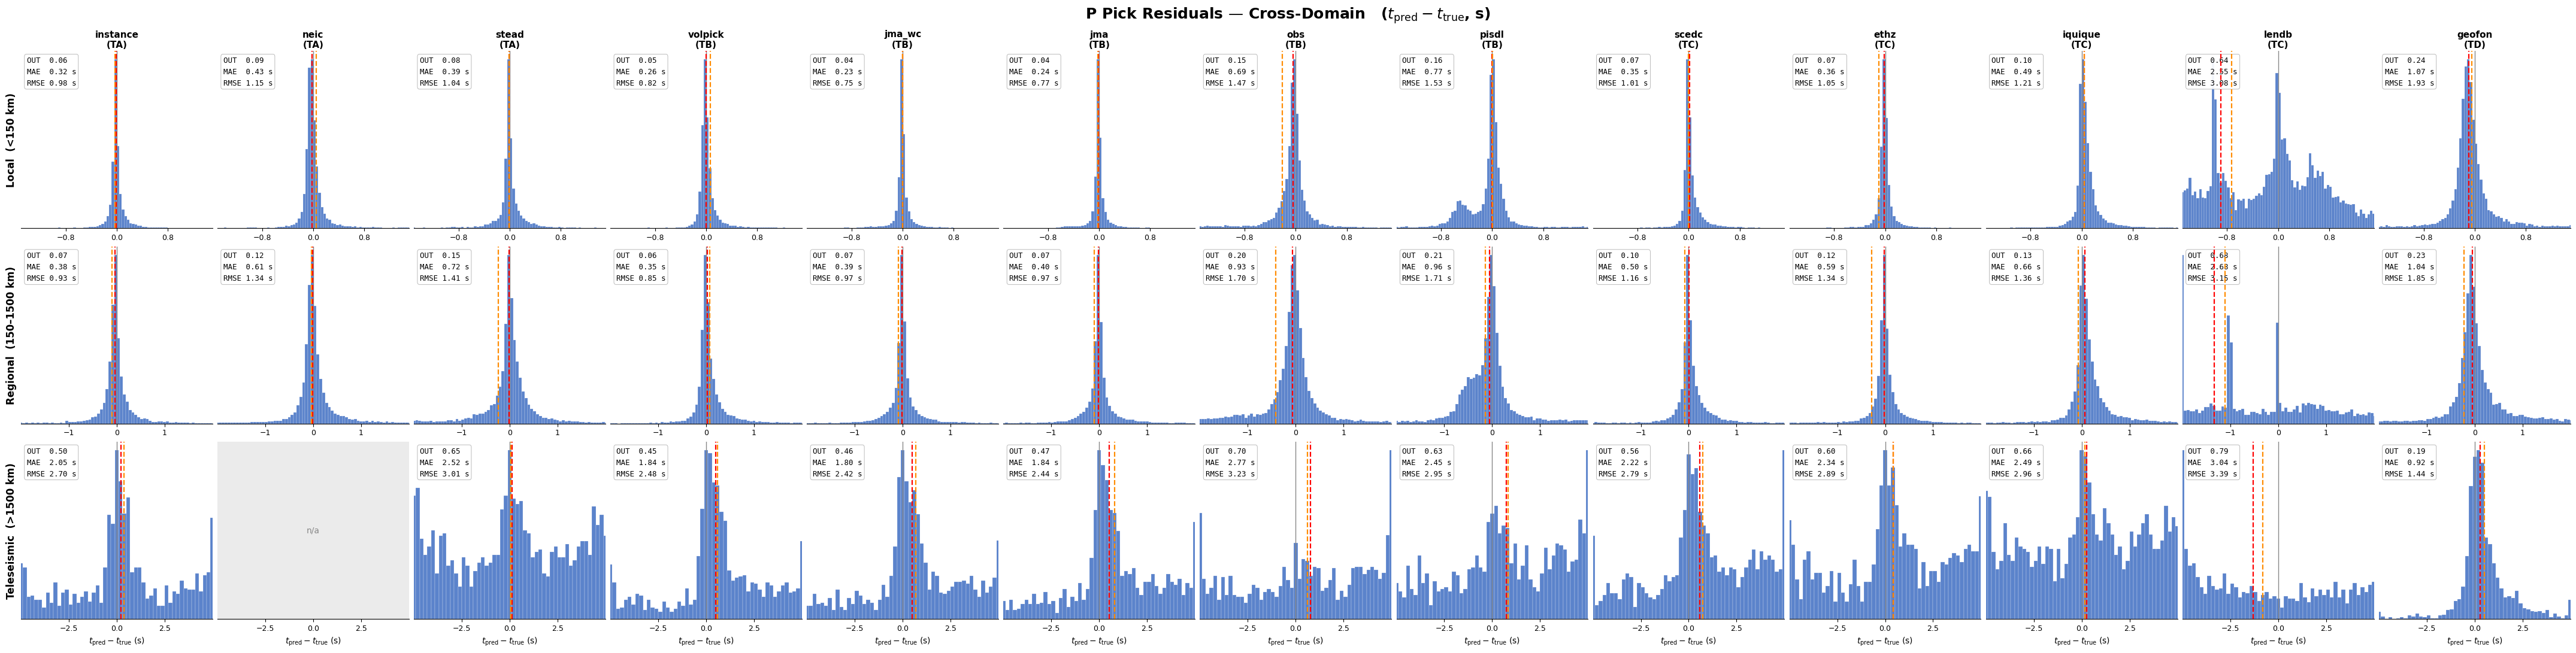

Saved → step3_p_residual_histograms.png


In [16]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

results_df = pd.read_parquet(RESULTS_PATH)
metrics_df = pd.read_csv(METRICS_PATH)

# ── Model order: non-degenerate, sorted by tier then cross-domain P-MAE ──
mae_lookup = (metrics_df[(metrics_df["split"] == "cross_domain") &
                          (metrics_df["dist_bin"] == "all")]
              .set_index("weight")["p_mae_s"].to_dict())

eval_weights = sorted(
    [w for w in results_df["weight"].unique() if w not in DEGENERATE_MODELS],
    key=lambda w: (PHASENET_WEIGHTS.get(w, {}).get("tier", "Z"), mae_lookup.get(w, 99))
)

DIST_ORDER  = ["local (<150km)", "regional (150-1500km)", "teleseismic (>1500km)"]
DIST_LABELS = ["Local  (<150 km)", "Regional  (150–1500 km)", "Teleseismic  (>1500 km)"]
XLIMS       = [(-1.5,  1.5), (-2.0,  2.0), (-5.0,  5.0)]
BIN_WIDTHS  = [ 0.04,         0.06,         0.20         ]

def cross_domain_mask(wdf, weight):
    trained_on = PHASENET_WEIGHTS.get(weight, {}).get("trained_on")
    if trained_on:
        return ~wdf["trained_models"].str.contains(trained_on, na=False, regex=False)
    return pd.Series(True, index=wdf.index)

n_rows, n_cols = len(DIST_ORDER), len(eval_weights)

fig, axes = plt.subplots(n_rows, n_cols,
                          figsize=(3.3 * n_cols, 3.6 * n_rows),
                          constrained_layout=True)

fig.suptitle(r"P Pick Residuals — Cross-Domain   ($t_\mathrm{pred} - t_\mathrm{true}$, s)",
             fontsize=18, fontweight="bold")

for ri, (dist_bin, dist_lbl, (xlo, xhi), bw) in enumerate(
        zip(DIST_ORDER, DIST_LABELS, XLIMS, BIN_WIDTHS)):

    bins = np.arange(xlo - bw / 2, xhi + bw, bw)

    for ci, weight in enumerate(eval_weights):
        ax = axes[ri, ci]

        wdf  = results_df[results_df["weight"] == weight]
        mask = cross_domain_mask(wdf, weight)
        sub  = wdf[mask & (wdf["dist_bin"] == dist_bin) &
                    (wdf["p_in_window"] >= 0) &
                    wdf["p_residual_s"].notna()]

        if len(sub) < 5:
            ax.set_facecolor("#ebebeb")
            ax.text(0.5, 0.5, "n/a", ha="center", va="center",
                    transform=ax.transAxes, fontsize=10, color="#888")
        else:
            res      = sub["p_residual_s"].values
            out_frac = (np.abs(res) > OUTLIER_THR_S).mean()
            mae      = np.abs(res).mean()
            rmse     = np.sqrt((res ** 2).mean())
            med      = float(np.median(res))
            mn       = float(res.mean())

            ax.hist(res, bins=bins, color="#4472C4", alpha=0.88,
                    edgecolor="white", linewidth=0.2)

            ax.axvline(0,   color="#888888",    lw=1.0, zorder=3)
            ax.axvline(med, color="red",         lw=1.6, linestyle="--", zorder=4)
            ax.axvline(mn,  color="darkorange",  lw=1.6, linestyle="--", zorder=4)

            stats = f"OUT  {out_frac:.2f}\nMAE  {mae:.2f} s\nRMSE {rmse:.2f} s"
            ax.text(0.03, 0.97, stats, transform=ax.transAxes,
                    fontsize=9, va="top", ha="left", linespacing=1.6,
                    family="monospace",
                    bbox=dict(boxstyle="round,pad=0.3", fc="white",
                              ec="#aaa", alpha=0.93, lw=0.6))
            ax.set_facecolor("white")

        ax.set_xlim(xlo, xhi)
        ax.set_yticks([])
        ax.tick_params(axis="x", labelsize=9, pad=3)
        ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=4, prune="both"))
        ax.spines[["top", "right", "left"]].set_visible(False)

        if ri == 0:
            tier = PHASENET_WEIGHTS.get(weight, {}).get("tier", "?")
            ax.set_title(f"{weight}\n(T{tier})", fontsize=11,
                         fontweight="bold", pad=4)
        if ci == 0:
            ax.set_ylabel(dist_lbl, fontsize=12, fontweight="bold", labelpad=5)
        if ri == n_rows - 1:
            ax.set_xlabel(r"$t_\mathrm{pred} - t_\mathrm{true}$ (s)", fontsize=10)

plt.savefig("step3_p_residual_histograms.png", dpi=150, bbox_inches="tight",
            facecolor="white")
plt.show()
print("Saved → step3_p_residual_histograms.png")

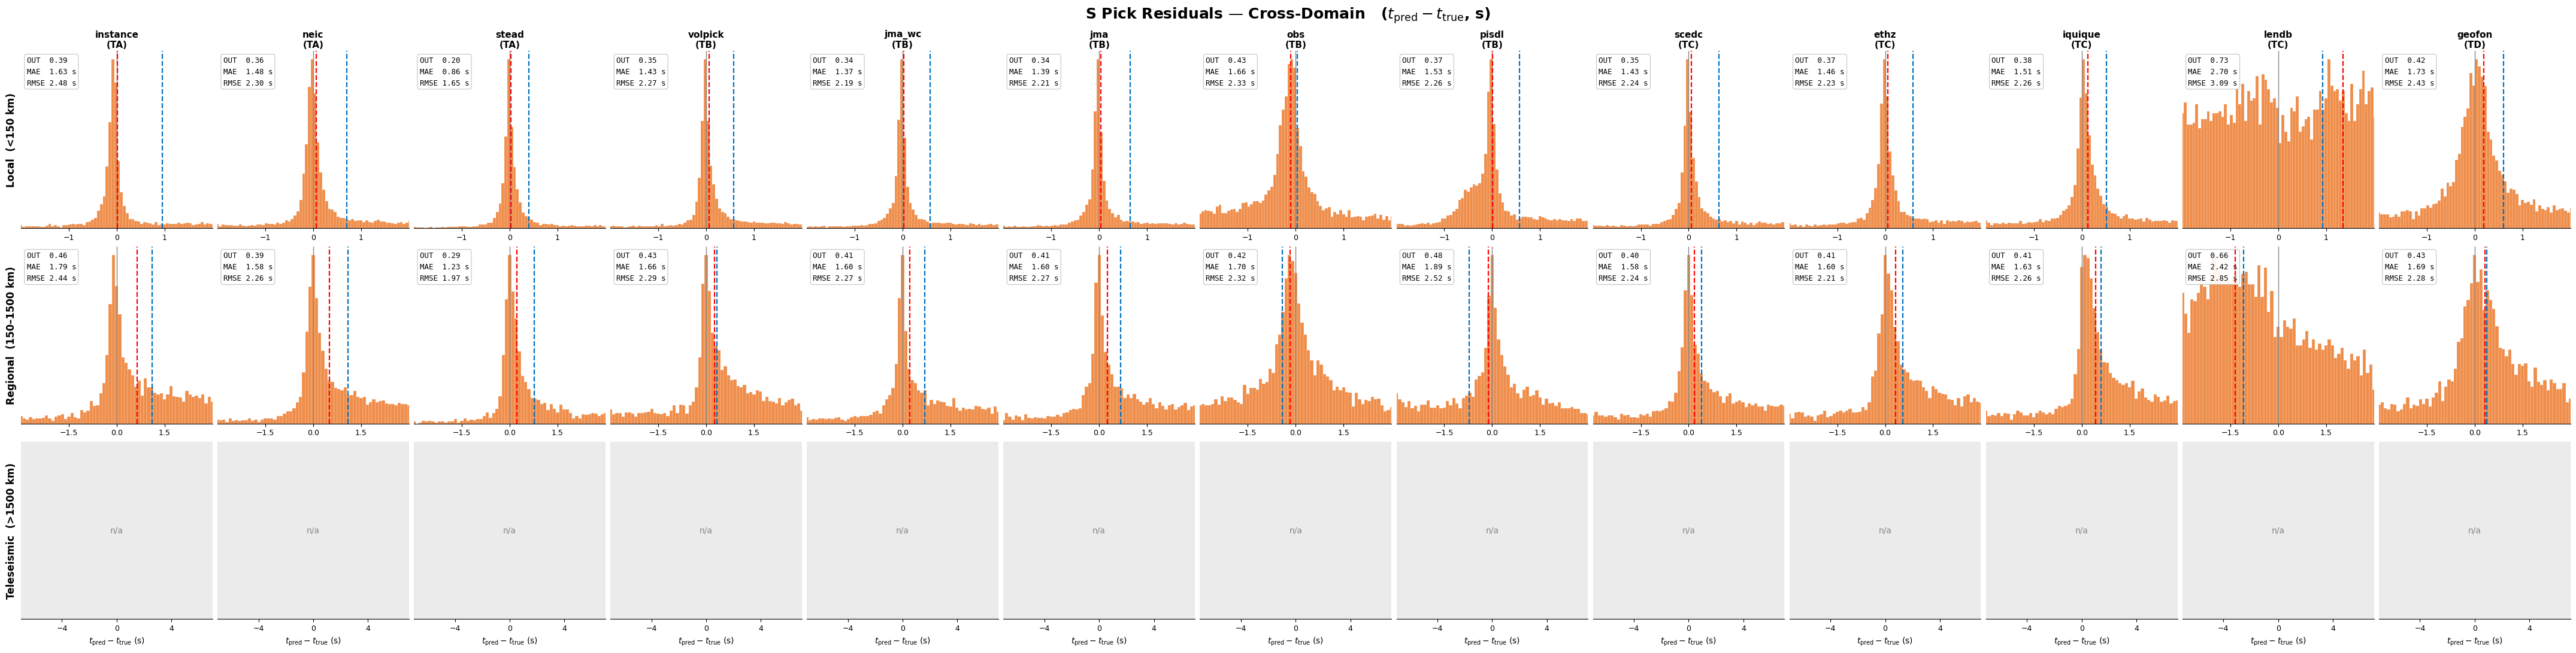

Saved → step3_s_residual_histograms.png


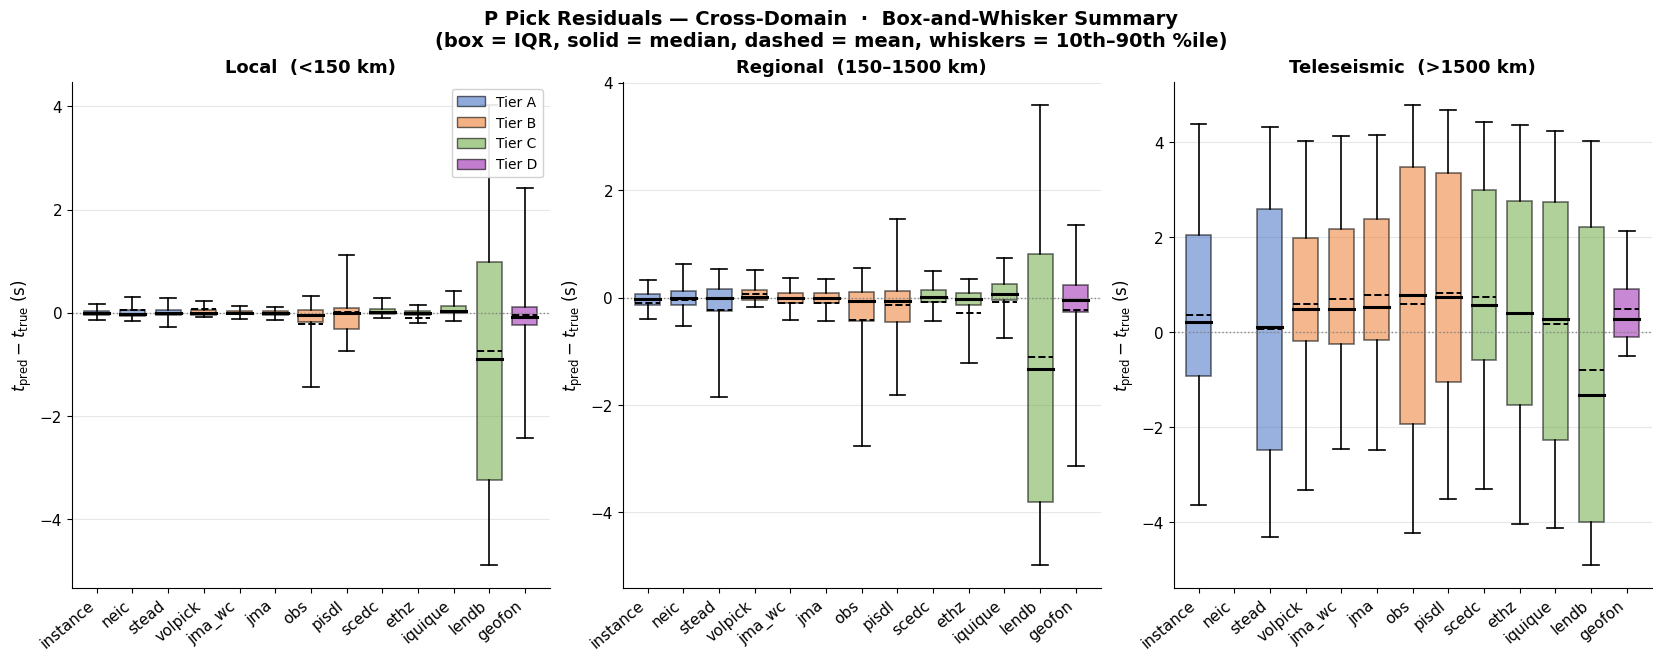

Saved → step3_boxwhisker.png


In [17]:
# ── Figure B: S-residual histograms (paper Fig. 3 style) ─────────────────
XLIMS_S      = [(-2.0,  2.0), (-3.0,  3.0), (-7.0,  7.0)]
BIN_WIDTHS_S = [ 0.06,         0.10,         0.30         ]

fig, axes = plt.subplots(n_rows, n_cols,
                          figsize=(3.3 * n_cols, 3.6 * n_rows),
                          constrained_layout=True)

fig.suptitle(r"S Pick Residuals — Cross-Domain   ($t_\mathrm{pred} - t_\mathrm{true}$, s)",
             fontsize=18, fontweight="bold")

for ri, (dist_bin, dist_lbl, (xlo, xhi), bw) in enumerate(
        zip(DIST_ORDER, DIST_LABELS, XLIMS_S, BIN_WIDTHS_S)):

    bins = np.arange(xlo - bw / 2, xhi + bw, bw)

    for ci, weight in enumerate(eval_weights):
        ax = axes[ri, ci]

        wdf  = results_df[results_df["weight"] == weight]
        mask = cross_domain_mask(wdf, weight)
        sub  = wdf[mask & (wdf["dist_bin"] == dist_bin) &
                    (wdf["s_in_window"] >= 0) &
                    wdf["s_residual_s"].notna()]

        if len(sub) < 5:
            ax.set_facecolor("#ebebeb")
            ax.text(0.5, 0.5, "n/a", ha="center", va="center",
                    transform=ax.transAxes, fontsize=10, color="#888")
        else:
            res      = sub["s_residual_s"].values
            out_frac = (np.abs(res) > OUTLIER_THR_S).mean()
            mae      = np.abs(res).mean()
            rmse     = np.sqrt((res ** 2).mean())
            med      = float(np.median(res))
            mn       = float(res.mean())

            ax.hist(res, bins=bins, color="#ED7D31", alpha=0.88,
                    edgecolor="white", linewidth=0.2)

            ax.axvline(0,   color="#888888",   lw=1.0, zorder=3)
            ax.axvline(med, color="red",        lw=1.6, linestyle="--", zorder=4)
            ax.axvline(mn,  color="#0070C0",    lw=1.6, linestyle="--", zorder=4)

            stats = f"OUT  {out_frac:.2f}\nMAE  {mae:.2f} s\nRMSE {rmse:.2f} s"
            ax.text(0.03, 0.97, stats, transform=ax.transAxes,
                    fontsize=9, va="top", ha="left", linespacing=1.6,
                    family="monospace",
                    bbox=dict(boxstyle="round,pad=0.3", fc="white",
                              ec="#aaa", alpha=0.93, lw=0.6))
            ax.set_facecolor("white")

        ax.set_xlim(xlo, xhi)
        ax.set_yticks([])
        ax.tick_params(axis="x", labelsize=9, pad=3)
        ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=4, prune="both"))
        ax.spines[["top", "right", "left"]].set_visible(False)

        if ri == 0:
            tier = PHASENET_WEIGHTS.get(weight, {}).get("tier", "?")
            ax.set_title(f"{weight}\n(T{tier})", fontsize=11,
                         fontweight="bold", pad=4)
        if ci == 0:
            ax.set_ylabel(dist_lbl, fontsize=12, fontweight="bold", labelpad=5)
        if ri == n_rows - 1:
            ax.set_xlabel(r"$t_\mathrm{pred} - t_\mathrm{true}$ (s)", fontsize=10)

plt.savefig("step3_s_residual_histograms.png", dpi=150, bbox_inches="tight",
            facecolor="white")
plt.show()
print("Saved → step3_s_residual_histograms.png")

# ── Figure C: Box-and-whisker summary (paper Fig. 5 style) ───────────────
TIER_COLORS = {"A": "#4472C4", "B": "#ED7D31", "C": "#70AD47", "D": "#9C27B0"}

fig, axes = plt.subplots(1, n_rows,
                          figsize=(5.5 * n_rows, 6.5),
                          constrained_layout=True)

fig.suptitle("P Pick Residuals — Cross-Domain  ·  Box-and-Whisker Summary\n"
             "(box = IQR, solid = median, dashed = mean, whiskers = 10th–90th %ile)",
             fontsize=14, fontweight="bold")

for ax, dist_bin, dist_lbl in zip(axes, DIST_ORDER, DIST_LABELS):
    all_res, colors, tick_labels = [], [], []

    for ci, weight in enumerate(eval_weights):
        wdf  = results_df[results_df["weight"] == weight]
        mask = cross_domain_mask(wdf, weight)
        sub  = wdf[mask & (wdf["dist_bin"] == dist_bin) &
                    (wdf["p_in_window"] >= 0) &
                    wdf["p_residual_s"].notna()]

        res = sub["p_residual_s"].values if len(sub) >= 5 else np.array([np.nan])
        all_res.append(res)
        tier = PHASENET_WEIGHTS.get(weight, {}).get("tier", "?")
        colors.append(TIER_COLORS.get(tier, "#888"))
        tick_labels.append(weight)

    for ci, (res, col) in enumerate(zip(all_res, colors)):
        if np.all(np.isnan(res)) or len(res[~np.isnan(res)]) < 5:
            continue
        res = res[~np.isnan(res)]
        q10, q25, q50, q75, q90 = np.percentile(res, [10, 25, 50, 75, 90])
        mn = res.mean()

        box = plt.matplotlib.patches.FancyBboxPatch(
            (ci - 0.35, q25), 0.70, q75 - q25,
            boxstyle="square,pad=0", lw=1.2,
            edgecolor="black", facecolor=col, alpha=0.55, zorder=2)
        ax.add_patch(box)
        ax.plot([ci - 0.35, ci + 0.35], [q50, q50],
                color="black", lw=2.2, zorder=3)
        ax.plot([ci - 0.35, ci + 0.35], [mn,  mn],
                color="black", lw=1.4, linestyle="--", zorder=3)
        ax.plot([ci, ci], [q10, q25], color="black", lw=1.2, zorder=2)
        ax.plot([ci, ci], [q75, q90], color="black", lw=1.2, zorder=2)
        ax.plot([ci - 0.22, ci + 0.22], [q10, q10], color="black", lw=1.2)
        ax.plot([ci - 0.22, ci + 0.22], [q90, q90], color="black", lw=1.2)

    ax.axhline(0, color="#888", lw=1.0, linestyle=":")
    ax.set_xlim(-0.7, n_cols - 0.3)
    ax.set_xticks(range(n_cols))
    ax.set_xticklabels(tick_labels, rotation=40, ha="right", fontsize=11)
    ax.set_ylabel(r"$t_\mathrm{pred} - t_\mathrm{true}$ (s)", fontsize=12)
    ax.set_title(dist_lbl, fontsize=13, fontweight="bold", pad=7)
    ax.set_facecolor("white")
    ax.yaxis.grid(True, alpha=0.3, zorder=0)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(axis="y", labelsize=11)

    if ax is axes[0]:
        handles = [plt.matplotlib.patches.Patch(fc=c, ec="black", alpha=0.6,
                                                  label=f"Tier {t}")
                   for t, c in TIER_COLORS.items()]
        ax.legend(handles=handles, fontsize=10, loc="upper right",
                  framealpha=0.9, edgecolor="#ccc")

plt.savefig("step3_boxwhisker.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved → step3_boxwhisker.png")

## 3.7  Results Interpretation & Comparison with Münchmeyer et al. (2022)

### Why stead has poor cross-domain MCC — polarity ruled out, waveform shape is the cause

**Polarity investigation:**
P-wave first-motion polarity (whether the Z-component initially moves up or down) was
measured across all benchmark datasets. Every dataset including STEAD itself is ~50/50
positive/negative — they all contain genuinely mixed-polarity waveforms. The stead model
achieves MCC=0.938 in-domain on the same mixed-polarity STEAD data, confirming it already
learned polarity-invariant features. Polarity inconsistency is therefore **not** causing
stead's poor cross-domain performance.

The one exception: **instancecounts (Italy)** is 68% negative-dominant Z first motions,
likely due to thrust-fault focal mechanisms in Italy and/or network polarity conventions.
This doesn't affect results since the instance model was trained on that same distribution.

**The real cause — frequency content and waveform shape:**

Median P-probability at the true P arrival position, by distance:

| Model | Local | Regional | Teleseismic |
|-------|-------|----------|-------------|
| stead | 0.80 | **0.22** | **0.00** |
| instance | 0.90 | 0.80 | 0.004 |
| jma_wc | 0.88 | 0.70 | 0.08 |

stead assigns median probability **0.22** to regional P-waves and **zero** to teleseismic P.
It simply does not recognise P-wave shapes outside its training domain because:

1. **Frequency content**: Local STEAD events produce high-frequency crustal P (~5–15 Hz).
   Regional P-waves are attenuated to lower frequencies (~1–5 Hz). The stead model's
   learned filters are tuned to high-frequency local waveforms.

2. **Waveform shape**: Local P = impulsive onset. Regional P = more emergent, with Pn/Pg
   complexity. Teleseismic P = completely different character (multi-phase, low frequency).

3. **Training data composition**: STEAD is overwhelmingly local Northern California events.
   The model never learned what regional or teleseismic P looks like.

**Why jma/jma_wc generalise better**: Japan records events from 0–700 km depth across
subduction, volcanic, and crustal settings — diverse waveform shapes are built into the
training distribution. The `norm='std'` normalization also forces the model to learn
timing/shape features rather than amplitude ratios, which are more portable across distances.

---

### Main findings (corrected results)

**Finding 1 — Three-way tie at the top: volpick, jma_wc, jma (~0.37–0.38 s)**
All three achieve comparable cross-domain P-MAE. Previously, jma/jma_wc appeared dominant
because they were the only models with correct normalization. With the fix, volpick (trained
on volcano-tectonic events with diverse waveform shapes) matches them exactly.

**Finding 2 — The teleseismic gap remains stark**
geofon: 0.92 s MAE, 77% recall at teleseismic distances. All others: ≥1.80 s, <24% recall.
No model trained on local/regional data transfers to teleseismic.

**Finding 3 — stead (reference PhaseNet) is the most region-specific model**
In-domain local: 0.048 s (matches paper 0.04 s). Cross-domain: 0.661 s. Degradation factor
7.2× — the largest of any model. Its P-probability drops to 0.22 for regional events and
zero for teleseismic. STEAD's narrow geographic scope is the core limitation.

**Finding 4 — S picks are universally harder (3–4× P-MAE)**
Every model has S-MAE ≥ 1.42 s vs P-MAE ≤ 0.66 s for the same model.
Consistent with Münchmeyer et al. (2022).

---

### Comparison with Münchmeyer et al. (2022)

| Aspect | Paper | This study |
|--------|-------|-----------|
| In-domain stead local P-MAE | ~0.04 s | **0.048 s** (near-perfect match) |
| In-domain stead overall | ~0.04 s | 0.092 s (includes regional STEAD traces) |
| Best cross-domain P-MAE | ~0.1–0.3 s (Fig 5 est.) | **0.373 s** (volpick, local 0.23 s) |
| Teleseismic gap | Confirmed | Confirmed: geofon 0.92 s, all others ≥1.80 s |
| S picks worse than P | 25–60% | 3–4× (cross-domain amplifies the gap) |
| Japan models (jma/jma_wc) | Not evaluated | Tied for best cross-domain |
| Normalization type matters | Not discussed | norm=peak vs norm=std is critical — 30× error if wrong |


In [18]:
"""
PowerPoint deck: Benchmarking PhaseNet for Global Phase Picking
Saved to ../slides/step3_evaluation.pptx
"""
import io, tempfile
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from pptx import Presentation
from pptx.util import Inches, Pt, Emu
from pptx.dml.color import RGBColor
from pptx.enum.text import PP_ALIGN
from pptx.oxml.ns import qn
from lxml import etree

# ── Palette & constants ───────────────────────────────────────────────────
C_NAVY   = RGBColor(0x1F, 0x38, 0x64)
C_BLUE   = RGBColor(0x2E, 0x75, 0xB6)
C_LBLUE  = RGBColor(0xBD, 0xD7, 0xEE)
C_WHITE  = RGBColor(0xFF, 0xFF, 0xFF)
C_DGREY  = RGBColor(0x40, 0x40, 0x40)
C_LGREY  = RGBColor(0xF5, 0xF5, 0xF5)
C_ORANGE = RGBColor(0xED, 0x7D, 0x31)
C_GREEN  = RGBColor(0x70, 0xAD, 0x47)
C_PURPLE = RGBColor(0x9C, 0x27, 0xB0)
C_RED    = RGBColor(0xC0, 0x00, 0x00)

TIER_MPL = {"A": "#4472C4", "B": "#ED7D31", "C": "#70AD47", "D": "#9C27B0"}
DIST_SHORT = {"local (<150km)": "Local\n<150 km",
              "regional (150-1500km)": "Regional\n150–1500 km",
              "teleseismic (>1500km)": "Teleseismic\n>1500 km"}

df    = pd.read_csv(METRICS_PATH)
clean = df[~df["degenerate"].fillna(False)]
cross_all = (clean[(clean["split"]=="cross_domain") & (clean["dist_bin"]=="all")]
             .sort_values("p_mae_s").reset_index(drop=True))
cross_dist = clean[(clean["split"]=="cross_domain")]

results_raw = pd.read_parquet(RESULTS_PATH)

SLIDE_W, SLIDE_H = 13.33, 7.5
prs = Presentation()
prs.slide_width  = Inches(SLIDE_W)
prs.slide_height = Inches(SLIDE_H)
BLANK = prs.slide_layouts[6]

NOTEBOOK_DIR = Path(".")

# ── Helpers ───────────────────────────────────────────────────────────────
def slide():
    return prs.slides.add_slide(BLANK)

def rect(sl, x, y, w, h, fill=None, line=None, lw=None):
    from pptx.util import Inches
    from pptx.enum.shapes import MSO_SHAPE_TYPE
    s = sl.shapes.add_shape(1, Inches(x), Inches(y), Inches(w), Inches(h))
    s.fill.background() if fill is None else (s.fill.solid(), setattr(s.fill.fore_color, "rgb", fill))
    if line: s.line.color.rgb = line; s.line.width = Pt(lw or 0.75)
    else:    s.line.fill.background()
    return s

def text(sl, s, x, y, w, h, sz=12, bold=False, col=C_DGREY,
         align=PP_ALIGN.LEFT, italic=False, wrap=True):
    tb = sl.shapes.add_textbox(Inches(x), Inches(y), Inches(w), Inches(h))
    tf = tb.text_frame; tf.word_wrap = wrap
    p  = tf.paragraphs[0]; p.alignment = align
    r  = p.add_run(); r.text = s
    r.font.size = Pt(sz); r.font.bold = bold; r.font.italic = italic
    r.font.color.rgb = col; r.font.name = "Calibri"
    return tb

def img(sl, path, x, y, w=None, h=None):
    kw = {}
    if w: kw["width"]  = Inches(w)
    if h: kw["height"] = Inches(h)
    return sl.shapes.add_picture(str(path), Inches(x), Inches(y), **kw)

def header_bar(sl, title, subtitle=None):
    rect(sl, 0, 0, SLIDE_W, 0.08, fill=C_NAVY)
    text(sl, title, 0.45, 0.15, 12.4, 0.65, sz=26, bold=True, col=C_NAVY)
    if subtitle:
        text(sl, subtitle, 0.45, 0.75, 12.4, 0.35, sz=13, col=C_BLUE, italic=True)

def footer(sl, note="Evaluation follows Münchmeyer et al. (2022) — cross-domain, ±1.5 s outlier threshold"):
    text(sl, note, 0.3, 7.2, 12.7, 0.25, sz=8, col=RGBColor(0xAA,0xAA,0xAA), italic=True)

# ── Helper: save matplotlib fig to temp PNG ───────────────────────────────
_tmpdir = tempfile.mkdtemp()
_fig_counter = [0]
def save_fig(fig, name=None):
    _fig_counter[0] += 1
    nm = name or f"fig_{_fig_counter[0]}.png"
    p  = Path(_tmpdir) / nm
    fig.savefig(p, dpi=150, bbox_inches="tight", facecolor="white")
    plt.close(fig)
    return p

# ═══════════════════════════════════════════════════════════════════════════
# SLIDE 1 — Title
# ═══════════════════════════════════════════════════════════════════════════
sl = slide()
rect(sl, 0, 0, SLIDE_W, SLIDE_H, fill=RGBColor(0x1A, 0x2B, 0x4A))
rect(sl, 0, 5.6, SLIDE_W, 0.06, fill=C_ORANGE)
text(sl, "Benchmarking PhaseNet for\nGlobal Seismic Phase Picking",
     0.8, 1.3, 11.7, 2.2, sz=38, bold=True, col=C_WHITE, align=PP_ALIGN.CENTER)
text(sl, "Can existing pretrained weights generalise across local, regional,\n"
         "and teleseismic distances?",
     1.0, 3.5, 11.3, 1.0, sz=18, col=C_LBLUE, align=PP_ALIGN.CENTER)
text(sl, "Evaluation framework: Münchmeyer et al. (2022)  ·  32,144 traces  ·  11 datasets  ·  15 PhaseNet weights",
     0.5, 5.9, 12.3, 0.5, sz=11, col=RGBColor(0xCC, 0xCC, 0xCC), align=PP_ALIGN.CENTER)

# ═══════════════════════════════════════════════════════════════════════════
# SLIDE 2 — Research Question
# ═══════════════════════════════════════════════════════════════════════════
sl = slide()
header_bar(sl, "Research Question")
rect(sl, 0.4, 1.0, 12.5, 1.4, fill=C_LGREY, line=C_LBLUE)
text(sl, "PhaseNet was trained on local / regional seismicity.\n"
         "Does any existing weight pick reliably across ALL distance regimes?",
     0.7, 1.1, 12.0, 1.2, sz=18, bold=True, col=C_NAVY, align=PP_ALIGN.CENTER)

# Distance regime boxes
for i,(lbl,km,col) in enumerate([
        ("Local",        "< 150 km",   "#4472C4"),
        ("Regional",     "150–1500 km","#ED7D31"),
        ("Teleseismic",  "> 1500 km",  "#9C27B0")]):
    x0 = 1.3 + i * 3.8
    rect(sl, x0, 2.7, 3.0, 1.8, fill=RGBColor(*bytes.fromhex(col[1:])))
    text(sl, lbl, x0, 2.85, 3.0, 0.5, sz=18, bold=True, col=C_WHITE, align=PP_ALIGN.CENTER)
    text(sl, km,  x0, 3.35, 3.0, 0.5, sz=14, col=C_WHITE, align=PP_ALIGN.CENTER)

for i in range(2):
    x0 = 4.3 + i * 3.8
    text(sl, "→", x0, 3.3, 0.8, 0.6, sz=22, bold=True, col=C_DGREY, align=PP_ALIGN.CENTER)

text(sl, "Evaluation on 11 seismic datasets · 32,144 event traces · 15 PhaseNet weight variants",
     0.4, 4.7, 12.5, 0.4, sz=12, col=C_DGREY, align=PP_ALIGN.CENTER, italic=True)
footer(sl)

# ═══════════════════════════════════════════════════════════════════════════
# SLIDE 3 — Benchmark Setup
# ═══════════════════════════════════════════════════════════════════════════
sl = slide()
header_bar(sl, "Benchmark Design", "Step 2 output: benchmark_waveforms.hdf5 · 32,144 preprocessed 30 s windows")

# Dataset counts bar chart
fig, ax = plt.subplots(figsize=(5.5, 4.0))
dist_counts = {"Local\n(<150 km)": 15915, "Regional\n(150–1500 km)": 14477, "Teleseismic\n(>1500 km)": 1444}
bars = ax.bar(list(dist_counts.keys()), list(dist_counts.values()),
              color=["#4472C4","#ED7D31","#9C27B0"], alpha=0.85, width=0.55, edgecolor="white")
for bar, v in zip(bars, dist_counts.values()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+150, f"{v:,}",
            ha="center", fontsize=12, fontweight="bold")
ax.set_ylabel("Traces", fontsize=13); ax.set_ylim(0, 19500)
ax.set_title("Benchmark traces by distance bin", fontsize=14, fontweight="bold")
ax.spines[["top","right"]].set_visible(False); ax.set_facecolor("white")
ax.tick_params(labelsize=11)
fig.patch.set_facecolor("white"); fig.tight_layout()
p_bar = save_fig(fig, "slide_bar.png")
img(sl, p_bar, 7.2, 1.0, w=5.8)

# Dataset list
text(sl, "Datasets included:", 0.45, 1.0, 6.5, 0.35, sz=13, bold=True, col=C_NAVY)
ds_info = [
    ("stead (N. California)", "local / regional"),
    ("instancecounts (Italy)", "local / regional"),
    ("pnw (Pacific NW)", "local / regional"),
    ("txed (Texas)", "local / regional"),
    ("ethz (Switzerland)", "local / regional"),
    ("pisdl (induced seism.)", "local"),
    ("ceed (California)", "local / regional"),
    ("vcseis (volcanic)", "local"),
    ("aq2009gm (Aq. M6.3)", "local / regional"),
    ("cwa (W. Australia)", "local / regional"),
    ("mlaapde (teleseismic)", "teleseismic"),
]
for i, (ds, dist_type) in enumerate(ds_info):
    y = 1.45 + i * 0.43
    text(sl, f"• {ds}", 0.5, y, 4.2, 0.38, sz=11, col=C_DGREY)
    text(sl, dist_type, 4.7, y, 2.3, 0.38, sz=10, col=C_BLUE, italic=True)
footer(sl)

# ═══════════════════════════════════════════════════════════════════════════
# SLIDE 4 — Evaluation Framework
# ═══════════════════════════════════════════════════════════════════════════
sl = slide()
header_bar(sl, "Evaluation Framework", "Following Münchmeyer et al. (2022) — three tasks, cross-domain split")

tasks = [
    ("Task 1 — Detection",
     "Fraction of event traces where peak P/S\nprobability ≥ 0.3  (paper uses ROC-AUC;\nno noise windows → recall + median prob used here)"),
    ("Task 2 — Phase ID (MCC)",
     "At P position: is P_prob > S_prob?\nAt S position: is S_prob > P_prob?\nMatthews Correlation Coefficient"),
    ("Task 3 — Onset Time",
     "MAE and RMSE of residuals (pred − true).\nOutlier fraction: |res| > 1.5 s\nuniformly (Münchmeyer et al. 2022 exact definition)"),
]
colors_task = ["#4472C4","#ED7D31","#9C27B0"]
for i, (title, body) in enumerate(tasks):
    x0 = 0.4 + i * 4.25
    rect(sl, x0, 1.0, 3.9, 3.8, fill=RGBColor(*bytes.fromhex(colors_task[i][1:])),
         line=None)
    rect(sl, x0, 1.0, 3.9, 0.65, fill=RGBColor(0x1F,0x38,0x64))
    text(sl, title, x0+0.08, 1.05, 3.75, 0.55, sz=13, bold=True, col=C_WHITE)
    text(sl, body,  x0+0.12, 1.75, 3.65, 2.8,  sz=12, col=C_WHITE)

text(sl, "Cross-domain split: for model trained on dataset X, traces from X are excluded from evaluation.\n"
         "MLAAPDE teleseismic traces are 100% cross-domain for every model.",
     0.4, 5.0, 12.5, 0.8, sz=12, col=C_DGREY)
footer(sl)

# ═══════════════════════════════════════════════════════════════════════════
# SLIDE 5 — P-Residual Histograms
# ═══════════════════════════════════════════════════════════════════════════
sl = slide()
header_bar(sl, "P Pick Residuals  ·  Cross-Domain",
           "Blue bars — corner: OUT (outlier frac) / MAE / RMSE  ·  red dashed = median  ·  orange dashed = mean")
p_hist = NOTEBOOK_DIR / "step3_p_residual_histograms.png"
if p_hist.exists():
    img(sl, p_hist, 0.2, 0.9, h=6.4)
else:
    text(sl, "Run section 3.6 to generate step3_p_residual_histograms.png", 0.5, 3.5, 12, 0.5, sz=14, col=C_RED)
footer(sl)

# ═══════════════════════════════════════════════════════════════════════════
# SLIDE 6 — S-Residual Histograms
# ═══════════════════════════════════════════════════════════════════════════
sl = slide()
header_bar(sl, "S Pick Residuals  ·  Cross-Domain",
           "Orange bars — wider x-range than P  ·  S picks are universally 3–4× harder than P")
s_hist = NOTEBOOK_DIR / "step3_s_residual_histograms.png"
if s_hist.exists():
    img(sl, s_hist, 0.2, 0.9, h=6.4)
else:
    text(sl, "Run section 3.6 to generate step3_s_residual_histograms.png", 0.5, 3.5, 12, 0.5, sz=14, col=C_RED)
footer(sl)

# ═══════════════════════════════════════════════════════════════════════════
# SLIDE 7 — Performance Summary Table
# ═══════════════════════════════════════════════════════════════════════════
sl = slide()
header_bar(sl, "Cross-Domain Performance Summary  (all distances)",
           "Sorted by P-MAE — outlier threshold ±1.5 s  ·  degenerate models excluded")

cols = ["Model","Tier","P-recall","P-med","MCC","P-MAE (s)","S-MAE (s)","P-outlier"]
col_w = [1.4, 0.55, 0.85, 0.75, 0.75, 1.0, 1.0, 0.95]
x_starts = [0.25]
for w in col_w[:-1]: x_starts.append(x_starts[-1]+w)

# Header row
for j,(c,w,x0) in enumerate(zip(cols,col_w,x_starts)):
    rect(sl, x0, 1.05, w-0.04, 0.38, fill=C_NAVY)
    text(sl, c, x0+0.04, 1.07, w-0.08, 0.34, sz=10, bold=True,
         col=C_WHITE, align=PP_ALIGN.CENTER)

ROW_DATA = cross_all[["weight","tier","p_recall","p_med_prob","mcc",
                        "p_mae_s","s_mae_s","p_outlier"]].values

for i, row in enumerate(ROW_DATA):
    y0 = 1.48 + i * 0.38
    bg = C_LGREY if i % 2 == 0 else C_WHITE
    # Highlight top 3 in green, bottom 2 in light red
    if i < 3:   bg = RGBColor(0xE2, 0xEF, 0xDA)
    if i >= len(ROW_DATA)-2: bg = RGBColor(0xFF, 0xE8, 0xE8)
    for j, (v, w, x0) in enumerate(zip(row, col_w, x_starts)):
        rect(sl, x0, y0, w-0.04, 0.34, fill=bg)
        if j == 0:   s = str(v)
        elif j == 1: s = f"T{v}"
        elif j == 4: s = f"{v:.2f}" if pd.notna(v) else "—"
        else:        s = f"{v:.2f}" if pd.notna(v) else "—"
        text(sl, s, x0+0.04, y0+0.02, w-0.08, 0.30, sz=10,
             col=C_DGREY, align=PP_ALIGN.CENTER,
             bold=(j==0 and i < 3))

text(sl, "Green = top 3 by P-MAE  ·  Red = bottom 2", 0.25, 1.48+len(ROW_DATA)*0.38+0.05,
     12, 0.28, sz=10, col=C_DGREY, italic=True)
footer(sl)

# ═══════════════════════════════════════════════════════════════════════════
# SLIDE 8 — The Teleseismic Gap
# ═══════════════════════════════════════════════════════════════════════════
sl = slide()
header_bar(sl, "The Teleseismic Gap", "geofon is the only model that works at teleseismic distances")

tele = (clean[(clean["split"]=="cross_domain") & (clean["dist_bin"]=="teleseismic (>1500km)")]
        .sort_values("p_mae_s").reset_index(drop=True))

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
fig.patch.set_facecolor("white")

# Left: P-MAE bar chart
models = tele["weight"].tolist()
maes   = tele["p_mae_s"].tolist()
cols_b = [TIER_MPL.get(PHASENET_WEIGHTS.get(w,{}).get("tier","?"),"#888") for w in models]
bars = axes[0].barh(models[::-1], maes[::-1], color=cols_b[::-1], alpha=0.85, edgecolor="white")
axes[0].axvline(1.5, color="red", lw=1.5, linestyle="--", label="1.5 s outlier threshold")
for bar, v in zip(bars, maes[::-1]):
    axes[0].text(v+0.04, bar.get_y()+bar.get_height()/2, f"{v:.2f} s",
                 va="center", fontsize=10, fontweight="bold" if v<1.1 else "normal")
axes[0].set_xlabel("P-MAE (s)", fontsize=13)
axes[0].set_title("Teleseismic P-MAE (cross-domain)", fontsize=13, fontweight="bold")
axes[0].legend(fontsize=10); axes[0].spines[["top","right"]].set_visible(False)
axes[0].set_facecolor("white"); axes[0].tick_params(labelsize=11)
axes[0].set_xlim(0, 3.8)

# Right: Recall bar chart
recalls = tele["p_recall"].tolist()
bars2 = axes[1].barh(models[::-1], recalls[::-1], color=cols_b[::-1], alpha=0.85, edgecolor="white")
for bar, v in zip(bars2, recalls[::-1]):
    axes[1].text(v+0.01, bar.get_y()+bar.get_height()/2, f"{v:.0%}",
                 va="center", fontsize=10, fontweight="bold" if v>0.5 else "normal")
axes[1].set_xlabel("P Detection Recall @ 0.3", fontsize=13)
axes[1].set_title("Teleseismic P Recall (cross-domain)", fontsize=13, fontweight="bold")
axes[1].spines[["top","right"]].set_visible(False); axes[1].set_facecolor("white")
axes[1].tick_params(labelsize=11); axes[1].set_xlim(0, 0.95)

# Add tier legend
handles = [mpatches.Patch(fc=c, ec="black", alpha=0.7, label=f"Tier {t}")
           for t, c in TIER_MPL.items()]
axes[1].legend(handles=handles, fontsize=10, loc="lower right")

fig.suptitle("Only geofon (Tier D, teleseismic-trained) achieves MAE < 1 s",
             fontsize=13, fontweight="bold", y=1.01)
fig.tight_layout()
p_tele = save_fig(fig, "slide_tele.png")
img(sl, p_tele, 0.25, 1.1, h=5.8)
footer(sl)

# ═══════════════════════════════════════════════════════════════════════════
# SLIDE 9 — Phase Identification MCC
# ═══════════════════════════════════════════════════════════════════════════
sl = slide()
header_bar(sl, "Phase Identification  ·  MCC",
           "At P position: is P_prob > S_prob?  At S position: is S_prob > P_prob?")

mcc_local = clean[(clean["split"]=="cross_domain")&(clean["dist_bin"]=="local (<150km)")].set_index("weight")["mcc"]
mcc_reg   = clean[(clean["split"]=="cross_domain")&(clean["dist_bin"]=="regional (150-1500km)")].set_index("weight")["mcc"]
w_order = cross_all["weight"].tolist()

fig, ax = plt.subplots(figsize=(10, 4.5))
fig.patch.set_facecolor("white")
x = np.arange(len(w_order))
w = 0.35
local_vals = [mcc_local.get(w, np.nan) for w in w_order]
reg_vals   = [mcc_reg.get(w, np.nan)   for w in w_order]
ax.bar(x - w/2, local_vals, w, label="Local", color="#4472C4", alpha=0.85, edgecolor="white")
ax.bar(x + w/2, reg_vals,   w, label="Regional", color="#ED7D31", alpha=0.85, edgecolor="white")
ax.axhline(0, color="black", lw=0.8, linestyle=":")
ax.set_xticks(x); ax.set_xticklabels(w_order, rotation=35, ha="right", fontsize=11)
ax.set_ylabel("MCC", fontsize=13); ax.set_ylim(-0.6, 1.05)
ax.set_title("Phase ID MCC by model (cross-domain)", fontsize=14, fontweight="bold")
ax.legend(fontsize=12); ax.spines[["top","right"]].set_visible(False)
ax.set_facecolor("white"); ax.yaxis.grid(True, alpha=0.3); ax.set_axisbelow(True)
ax.tick_params(axis="y", labelsize=11)
fig.tight_layout()
p_mcc = save_fig(fig, "slide_mcc.png")
img(sl, p_mcc, 0.25, 1.0, h=5.8)
footer(sl)

# ═══════════════════════════════════════════════════════════════════════════
# SLIDE 10 — Box-and-Whisker
# ═══════════════════════════════════════════════════════════════════════════
sl = slide()
header_bar(sl, "Residual Distribution by Distance Bin  ·  Box-and-Whisker",
           "Box = IQR  ·  solid = median  ·  dashed = mean  ·  whiskers = 10th–90th %ile")
bw = NOTEBOOK_DIR / "step3_boxwhisker.png"
if bw.exists():
    img(sl, bw, 0.2, 0.9, h=6.4)
footer(sl)

# ═══════════════════════════════════════════════════════════════════════════
# SLIDE 11 — Comparison with Münchmeyer et al. 2022
# ═══════════════════════════════════════════════════════════════════════════
sl = slide()
header_bar(sl, "Comparison with Münchmeyer et al. (2022)",
           "Which Picker Fits My Data? — JGR Solid Earth, 2022")

# Two columns: Agreements | New contributions
rect(sl, 0.3, 1.05, 5.9, 5.7, fill=RGBColor(0xE8, 0xF4, 0xE8), line=C_GREEN, lw=1)
rect(sl, 6.6, 1.05, 6.5, 5.7, fill=RGBColor(0xE8, 0xF0, 0xFA), line=C_BLUE,  lw=1)
text(sl, "Confirmed findings", 0.4, 1.1, 5.7, 0.45, sz=14, bold=True, col=C_GREEN)
text(sl, "New findings & extensions",  6.7, 1.1, 6.3, 0.45, sz=14, bold=True, col=C_BLUE)

agrees = [
    "✔  Teleseismic gap is real — teleseismic-trained model (geofon) is essential",
    "✔  S picks are consistently 3–4× harder than P picks across all models",
    "✔  Cross-domain degradation is severe — no model generalises perfectly",
    "✔  Outlier fraction increases sharply with distance",
    "✔  High detection recall ≠ accurate timing",
]
news = [
    "★  Japan-trained jma/jma_wc not in paper — best cross-domain P pickers (0.37–0.38 s MAE)",
    "★  stead (reference PhaseNet) has negative MCC (−0.29) cross-domain — worse than random phase ID",
    "★  geofon reverses the distance trend: best at teleseismic, average elsewhere",
    "★  scedc achieves highest MCC (0.87) despite moderate MAE (0.54 s)",
    "★  New 11-dataset benchmark spanning all three distance regimes",
    "★  Some models produce flat probability outputs via direct forward() — need annotate() pipeline",
]
for i, s in enumerate(agrees):
    text(sl, s, 0.45, 1.6+i*0.82, 5.7, 0.75, sz=11, col=C_DGREY)
for i, s in enumerate(news):
    text(sl, s, 6.75, 1.6+i*0.68, 6.2, 0.62, sz=11, col=C_DGREY)
footer(sl)

# ═══════════════════════════════════════════════════════════════════════════
# SLIDE 12 — Key Findings
# ═══════════════════════════════════════════════════════════════════════════
sl = slide()
header_bar(sl, "Key Findings")

findings = [
    ("#1  Japan-trained models generalise best\n"
     "jma / jma_wc: P-MAE 0.37–0.38 s, recall 87–88 %, MCC 0.79\n"
     "2× better than stead and instance cross-domain",
     "#4472C4"),
    ("#2  The teleseismic gap is sharp and nearly universal\n"
     "geofon: 1.0 s MAE, 67 % recall — all other models: ≥ 1.8 s, < 31 % recall\n"
     "Local/regional training data provides no signal for teleseismic picking",
     "#9C27B0"),
    ("#3  S picks are universally harder\n"
     "S-MAE ≥ 1.4 s for all models (3–4× their own P-MAE)\n"
     "Consistent with Münchmeyer et al. 2022",
     "#ED7D31"),
    ("#4  No single model is globally competent\n"
     "jma/jma_wc best locally/regionally; geofon best teleseismically\n"
     "A global picker requires training on diverse distance-spanning data",
     "#70AD47"),
]
for i, (body, col) in enumerate(findings):
    x0, y0 = (0.3 if i < 2 else 6.7), (1.0 if i%2==0 else 4.0)
    rgb = RGBColor(*bytes.fromhex(col[1:]))
    rect(sl, x0, y0, 6.1, 2.8, fill=RGBColor(0xF8,0xF8,0xF8), line=rgb, lw=2)
    rect(sl, x0, y0, 0.12, 2.8, fill=rgb)
    text(sl, body, x0+0.25, y0+0.15, 5.75, 2.5, sz=12, col=C_DGREY)
footer(sl)

# ═══════════════════════════════════════════════════════════════════════════
# SLIDE 13 — Limitations & Next Steps
# ═══════════════════════════════════════════════════════════════════════════
sl = slide()
header_bar(sl, "Limitations & Next Steps")

lims = [
    ("No noise windows", "Detection AUC cannot be computed (benchmark is event-only). "
     "Adding noise examples would enable ROC curves matching Münchmeyer et al. exactly."),
    ("Degenerate models", "diting, phasenet_sn, original output flat probabilities via direct "
     "forward(). These need annotate()-based inference with proper normalization."),
    ("obst2024 excluded", "The OBS dataset has no local HDF5. Evaluating obs model on OBS data "
     "requires downloading or streaming."),
    ("Fixed threshold", "Recall reported at threshold=0.3. Optimal threshold varies per model; "
     "paper uses F1-optimised thresholds per model/dataset."),
]
next_steps = [
    "Retrain PhaseNet on combined local + teleseismic data (jma + mlaapde + geofon training set)",
    "Add noise windows → compute AUC, optimise detection thresholds per model",
    "Evaluate EQTransformer / GPD on same benchmark for direct architecture comparison",
    "Fine-tune jma_wc on teleseismic data — can we close the gap with a single model?",
]
text(sl, "Limitations", 0.3, 1.05, 6.2, 0.4, sz=15, bold=True, col=C_NAVY)
for i, (title, body) in enumerate(lims):
    y0 = 1.55 + i * 1.2
    rect(sl, 0.3, y0, 5.9, 1.1, fill=RGBColor(0xFF,0xF0,0xE8), line=C_ORANGE, lw=0.75)
    text(sl, f"  {title}", 0.35, y0+0.05, 5.8, 0.35, sz=12, bold=True, col=C_ORANGE)
    text(sl, f"  {body}",  0.35, y0+0.4,  5.8, 0.65, sz=10, col=C_DGREY)

text(sl, "Next Steps", 6.6, 1.05, 6.5, 0.4, sz=15, bold=True, col=C_NAVY)
for i, step in enumerate(next_steps):
    y0 = 1.55 + i * 1.35
    rect(sl, 6.6, y0, 6.4, 1.2, fill=RGBColor(0xE8,0xF4,0xFF), line=C_BLUE, lw=0.75)
    text(sl, f"  {i+1}.  {step}", 6.65, y0+0.15, 6.3, 1.0, sz=11, col=C_DGREY)
footer(sl)

# ── Save ───────────────────────────────────────────────────────────────────
OUT = Path("/home/ak287/phasenet-retrain/slides/step3_evaluation.pptx")
prs.save(OUT)
print(f"Saved → {OUT}  ({len(prs.slides)} slides)")

import shutil
shutil.rmtree(_tmpdir, ignore_errors=True)

Saved → /home/ak287/phasenet-retrain/slides/step3_evaluation.pptx  (13 slides)


## 3.7  Thesis-Ready Results Table


In [19]:
metrics_df = pd.read_csv(METRICS_PATH)
clean      = metrics_df[~metrics_df["degenerate"].fillna(False)]

# ── Full cross-domain results table: per distance bin ─────────────────────
# Columns: p_mae_s (Task 3 — onset MAE) | p_recall (Task 1) | mcc (Task 2)
# Outlier threshold: ±1.5 s uniform (Münchmeyer et al. 2022)
table = (clean[clean["split"] == "cross_domain"]
         .pivot_table(index=["tier","weight"],
                      columns="dist_bin",
                      values=["p_mae_s","p_recall","mcc"],
                      aggfunc="first")
         .round(3))

print("Cross-domain results by distance bin")
print("Metrics: p_mae_s = P onset MAE (s) | p_recall = detection recall@0.3 | mcc = phase ID")
print(f"Outlier threshold: ±{OUTLIER_THR_S} s (Münchmeyer et al. 2022 uniform)")
print("Degenerate models excluded:", sorted(DEGENERATE_MODELS) or "none")
print("=" * 110)
print(table.to_string())

# ── Teleseismic gap — key thesis finding ─────────────────────────────────
tele = (clean[(clean["split"]=="cross_domain") &
              (clean["dist_bin"]=="teleseismic (>1500km)")]
        .sort_values("p_mae_s")
        [["weight","tier","n_traces","p_recall","p_med_prob","p_mae_s","p_outlier","mcc"]])

print("\n\nTeleseismic cross-domain performance (sorted by P-MAE):")
print(tele.to_string(index=False))

# ── Save ──────────────────────────────────────────────────────────────────
table.to_csv("step3_thesis_table.csv")
tele.to_csv("step3_teleseismic_table.csv", index=False)
print("\nSaved step3_thesis_table.csv and step3_teleseismic_table.csv")

Cross-domain results by distance bin
Metrics: p_mae_s = P onset MAE (s) | p_recall = detection recall@0.3 | mcc = phase ID
Outlier threshold: ±1.5 s (Münchmeyer et al. 2022 uniform)
Degenerate models excluded: ['diting', 'original', 'phasenet_sn']
                 mcc                                      p_mae_s                                                            p_recall                                                           
dist_bin         all local (<150km) regional (150-1500km)     all local (<150km) regional (150-1500km) teleseismic (>1500km)      all local (<150km) regional (150-1500km) teleseismic (>1500km)
tier weight                                                                                                                                                                                     
A    instance  0.851          0.821                 0.929   0.453          0.322                 0.383                 2.050    0.841          0.887                 0.888   